In [ ]:
channel_rows = [
    {"ch": "search",   "impression": 320000, "click_counts": 19200, "ctr": 0.06, "visit_counts": 17500, "sign": 1050, "sign_rate": 0.06, "cac": 28000},
    {"ch": "sns",      "impression": 500000, "click_counts": 20000, "ctr": 0.04, "visit_counts": 18200, "sign": 728,  "sign_rate": 0.04, "cac": 41000},
    {"ch": "youtube",  "impression": 210000, "click_counts": 6300,  "ctr": 0.03, "visit_counts": 5900,  "sign": 236,  "sign_rate": 0.04, "cac": 48000},
    {"ch": "content",  "impression": 85000,  "click_counts": 5950,  "ctr": 0.07, "visit_counts": 5400,  "sign": 486,  "sign_rate": 0.09, "cac": 15000},
    {"ch": "referral/recommend", "impression": 40000,  "click_counts": 2400,  "ctr": 0.06, "visit_counts": 2250,  "sign": 270,  "sign_rate": 0.12, "cac": 11000},
]

segment_rows = [
    {"segment": "student",    "visit_share": 0.18, "sign_rate": 0.032},
    {"segment": "worker",     "visit_share": 0.37, "sign_rate": 0.078},
    {"segment": "freelancer", "visit_share": 0.24, "sign_rate": 0.069},
    {"segment": "team",       "visit_share": 0.21, "sign_rate": 0.054},
]

funnel_rows = [
    {"step": "landing",      "count": 49250, "drop_rate": None},
    {"step": "introduction",        "count": 39400, "drop_rate": 0.20},
    {"step": "price_section",      "count": 21670, "drop_rate": 0.45},
    {"step": "signup_click", "count": 9850,  "drop_rate": 0.545},
    {"step": "signup_done",  "count": 2770,  "drop_rate": 0.719}, ]

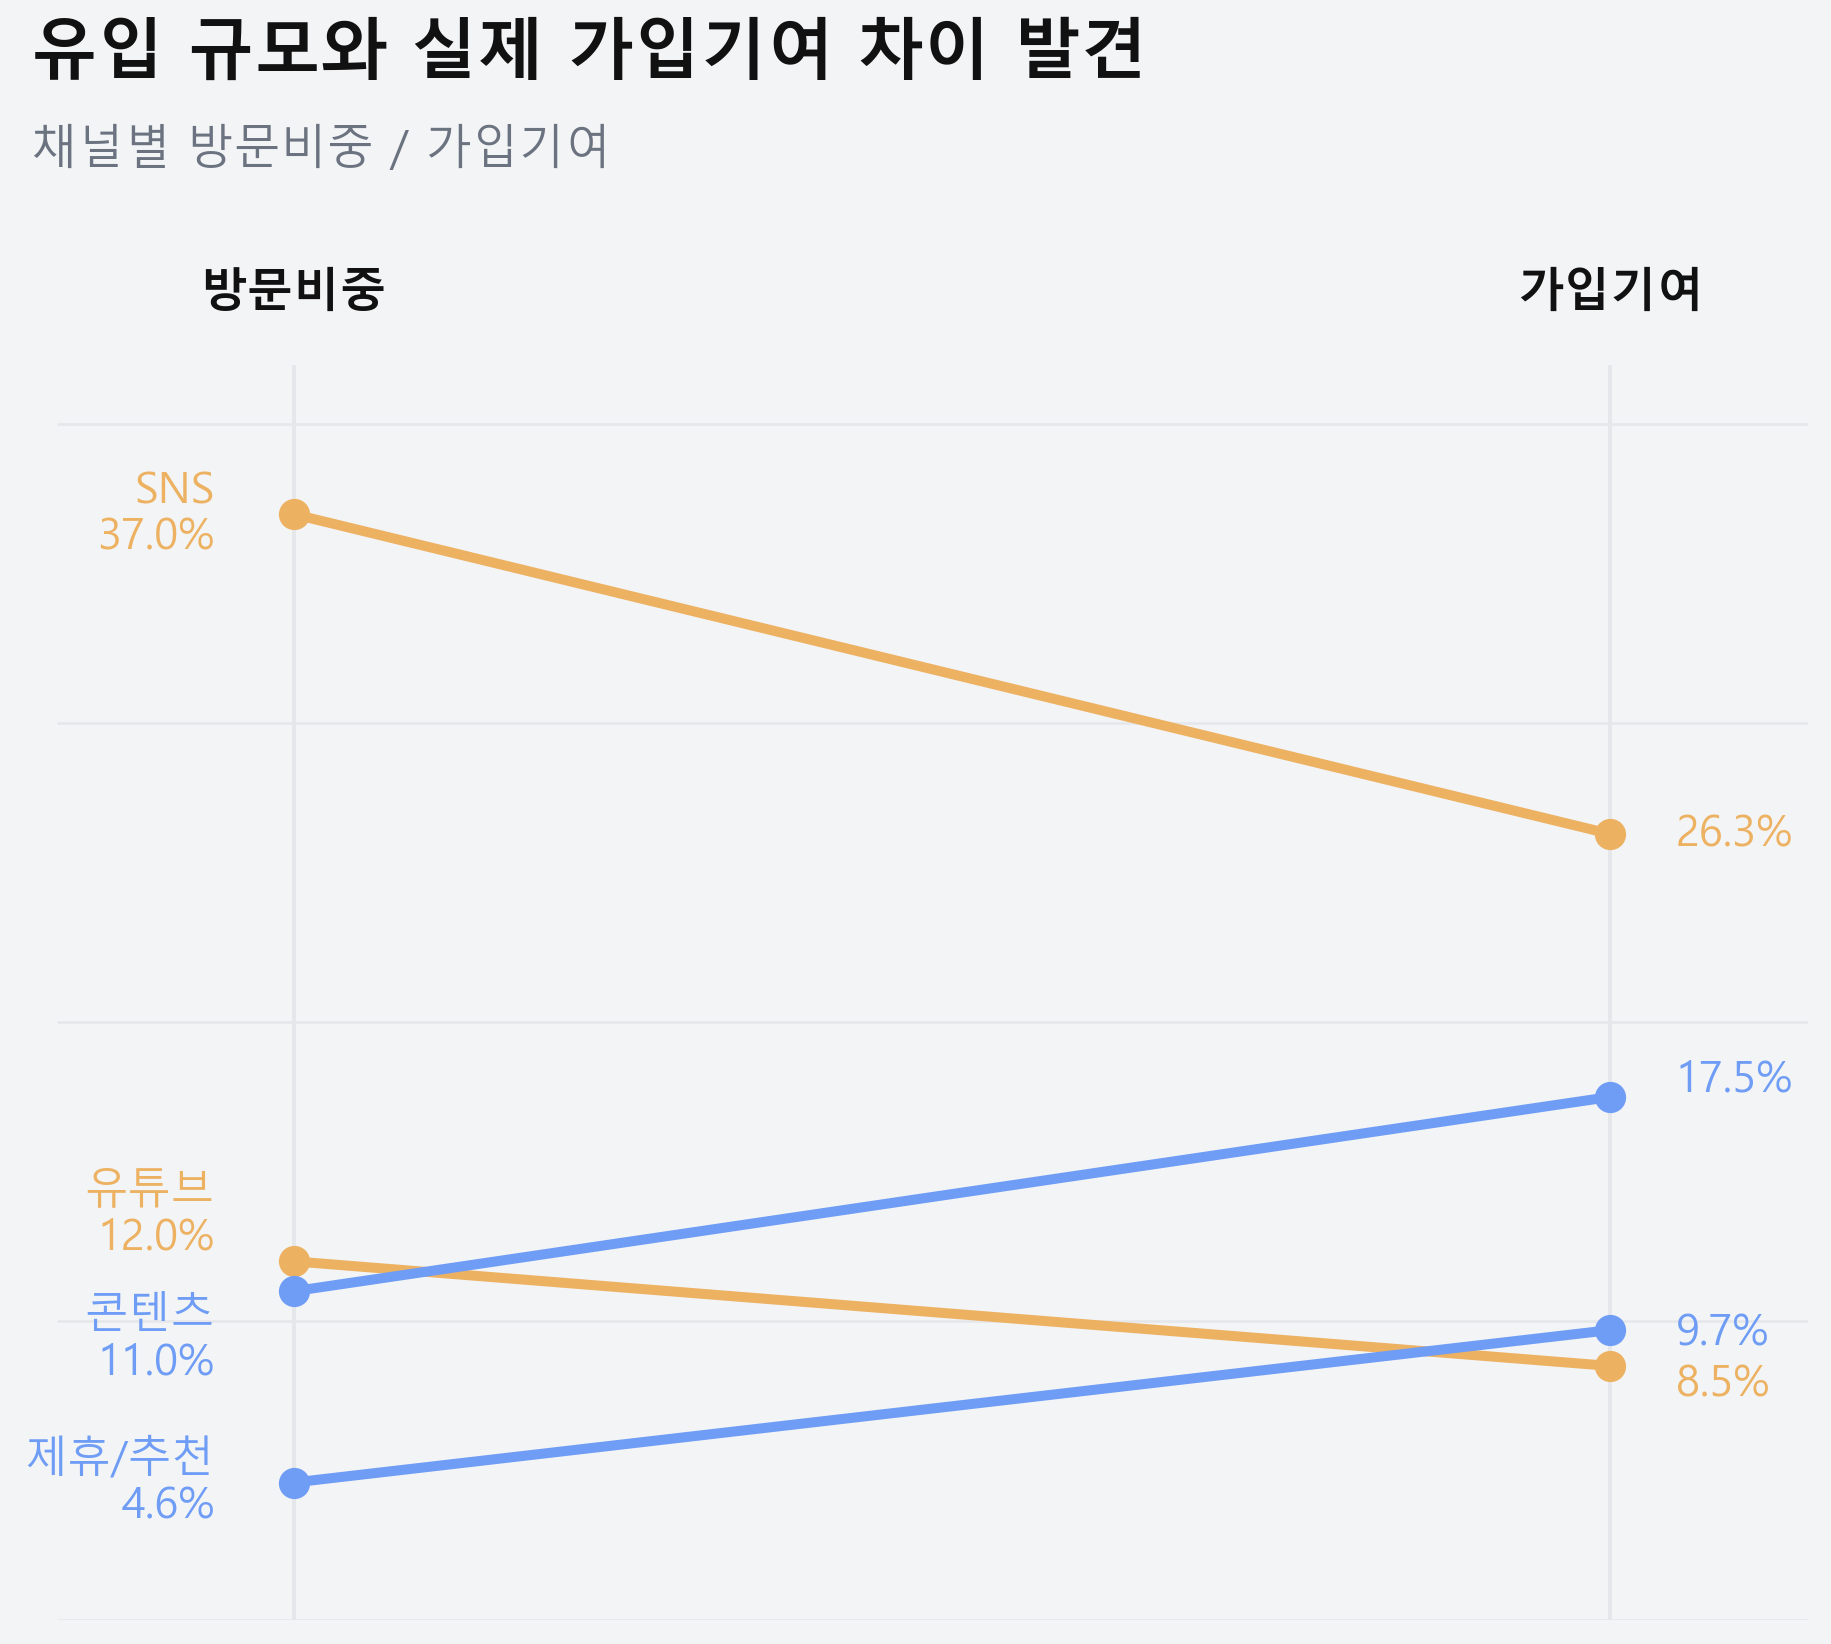

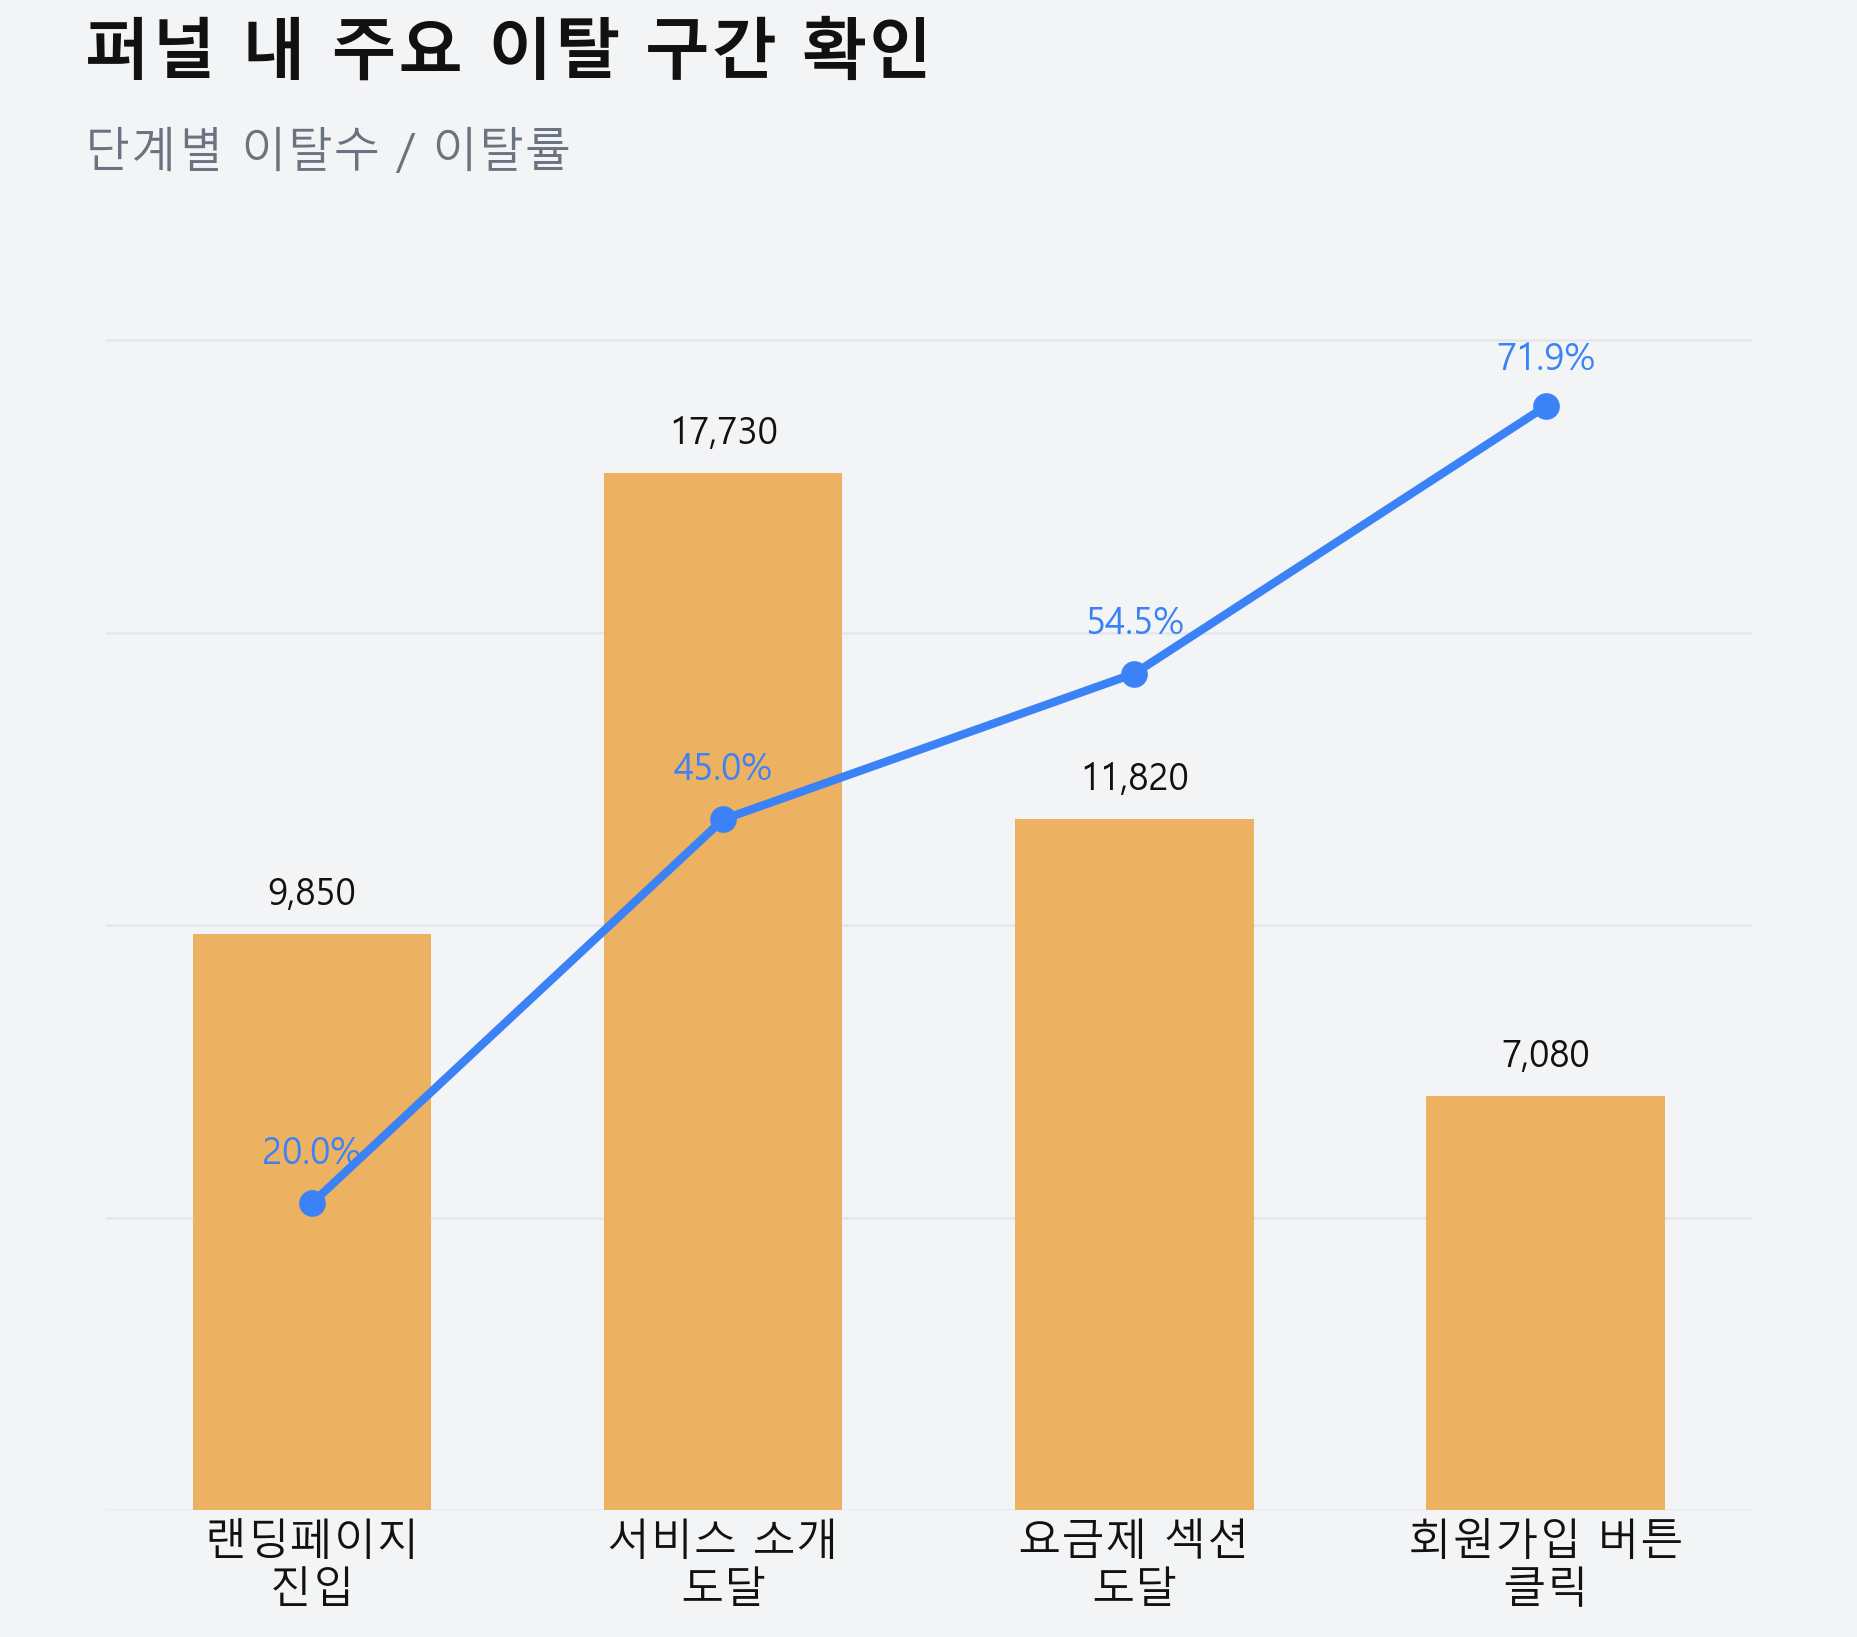

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

# =========================
# 0) 한글 폰트 자동 탐색
# =========================
preferred_fonts = [
    "AppleGothic",        # macOS
    "Malgun Gothic",      # Windows
    "NanumGothic",
    "NanumSquare",
    "Noto Sans CJK KR",
    "Noto Sans KR",
    "DejaVu Sans"
]

available_fonts = {f.name for f in fm.fontManager.ttflist}
FONT = next((f for f in preferred_fonts if f in available_fonts), "DejaVu Sans")

plt.rcParams["axes.unicode_minus"] = False

# =========================
# 1) 공통 스타일
# =========================
BG = "#F3F4F6"
TEXT = "#111111"
SUBTEXT = "#6B7280"
GRID = "#E5E7EB"
BLUE = "#6F9DF5"
BLUE_DARK = "#3B82F6"
ORANGE = "#EDB162"

TITLE_SIZE = 20
SUBTITLE_SIZE = 14
LABEL_SIZE = 13
TICK_SIZE = 13
VALUE_SIZE = 11

def style_axis(ax):
    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

# =========================
# 2) 데이터
# =========================
# 검색광고 제외
channels = ["SNS", "유튜브", "콘텐츠", "제휴/추천"]
visit_share = np.array([37.0, 12.0, 11.0, 4.6])
signup_share = np.array([26.3, 8.5, 17.5, 9.7])

# 퍼널
funnel_labels = [
    "랜딩페이지\n진입",
    "서비스 소개\n도달",
    "요금제 섹션\n도달",
    "회원가입 버튼\n클릭"
]
drop_counts = np.array([9850, 17730, 11820, 7080])
drop_rates = np.array([20.0, 45.0, 54.5, 71.9])

# =========================
# 3) 차트 1: 슬로프 차트
# =========================
def plot_slope_chart():
    fig, ax = plt.subplots(figsize=(8.3, 7.2), facecolor=BG, dpi=240)
    ax.set_position([0.08, 0.12, 0.84, 0.72])
    style_axis(ax)
    

    x_left, x_right = 0, 1

    # 기준선
    ax.vlines([x_left, x_right], ymin=0, ymax=42, colors=GRID, lw=1.2)
    for y in [0, 10, 20, 30, 40]:
        ax.hlines(y, -0.18, 1.18, colors=GRID, lw=0.8, zorder=0)

    # 겹침 방지용 라벨 오프셋
    left_offsets = {
        "SNS": 0.0,
        "유튜브": 1.6,
        "콘텐츠": -1.6,
        "제휴/추천": 0.0
    }
    right_offsets = {
        "SNS": 0.0,
        "유튜브": -0.6,
        "콘텐츠": 0.6,
        "제휴/추천": -0.1
    }

    for ch, v, s in zip(channels, visit_share, signup_share):
        color = BLUE if s >= v else ORANGE

        ax.plot([x_left, x_right], [v, s], color=color, lw=3, zorder=2)
        ax.scatter([x_left, x_right], [v, s], s=70, color=color, zorder=3)

        # 왼쪽: 채널명 + 방문비중
        ax.text(
            x_left - 0.06, v + left_offsets[ch],
            f"{ch}\n{v:.1f}%",
            ha="right", va="center",
            fontsize=LABEL_SIZE, color=color, fontfamily=FONT,
            linespacing=1.1
        )

        # 오른쪽: 가입기여 값만
        ax.text(
            x_right + 0.05, s + right_offsets[ch],
            f"{s:.1f}%",
            ha="left", va="center",
            fontsize=LABEL_SIZE, color=color, fontfamily=FONT
        )

    # 헤더
    ax.text(
        x_left, 43.6, "방문비중",
        ha="center", va="bottom",
        fontsize=14, color=TEXT, fontfamily=FONT, fontweight="bold"
    )
    ax.text(
        x_right, 43.6, "가입기여",
        ha="center", va="bottom",
        fontsize=14, color=TEXT, fontfamily=FONT, fontweight="bold"
    )

    # 제목 / 부제목
    fig.text(
        0.07, 0.965,
        "유입 규모와 실제 가입기여 차이 발견",
        ha="left", va="top",
        fontsize=TITLE_SIZE, fontweight="bold",
        color=TEXT, fontfamily=FONT
    )
    fig.text(
        0.07, 0.905,
        "채널별 방문비중 / 가입기여",
        ha="left", va="top",
        fontsize=SUBTITLE_SIZE,
        color=SUBTEXT, fontfamily=FONT
    )

    ax.set_xlim(-0.18, 1.15)
    ax.set_ylim(0, 45)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout(rect=[0, 0.02, 1, 0.84])
    plt.savefig("01_유입규모와_가입기여_괴리_발견_v2.png", dpi=220, bbox_inches="tight", facecolor=BG)
    plt.show()

# =========================
# 4) 차트 2: 퍼널 병목 차트
# =========================
def plot_funnel_chart():
    fig, ax = plt.subplots(figsize=(8.0, 7.4), facecolor=BG, dpi=240)
    style_axis(ax)

    x = np.arange(len(funnel_labels))

    # 막대
    bars = ax.bar(x, drop_counts, width=0.58, color=ORANGE, edgecolor="none", zorder=2)

    # 막대값
    for rect, val in zip(bars, drop_counts):
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 350,
            f"{val:,}",
            ha="center", va="bottom",
            fontsize=VALUE_SIZE, color=TEXT, fontfamily=FONT
        )

    # 보조축 라인
    ax2 = ax.twinx()
    style_axis(ax2)
    ax2.plot(x, drop_rates, color=BLUE_DARK, marker="o", markersize=7, lw=2.5, zorder=3)

    # 이탈률 라벨
    rate_y_offsets = [2.0, 2.0, 2.0, 1.8]
    for xi, rate, dy in zip(x, drop_rates, rate_y_offsets):
        ax2.text(
            xi, rate + dy,
            f"{rate:.1f}%",
            ha="center", va="bottom",
            fontsize=VALUE_SIZE, color=BLUE_DARK, fontfamily=FONT
        )

    # 가이드라인
    for y in [0, 5000, 10000, 15000, 20000]:
        ax.hlines(y, -0.5, len(x)-0.5, colors=GRID, lw=0.8, zorder=0)

    # 제목 / 부제목
    fig.text(
        0.07, 0.965,
        "퍼널 내 주요 이탈 구간 확인",
        ha="left", va="top",
        fontsize=TITLE_SIZE, fontweight="bold",
        color=TEXT, fontfamily=FONT
    )
    fig.text(
        0.07, 0.905,
        "단계별 이탈수 / 이탈률",
        ha="left", va="top",
        fontsize=SUBTITLE_SIZE,
        color=SUBTEXT, fontfamily=FONT
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        funnel_labels,
        fontsize=TICK_SIZE,
        color=TEXT,
        fontfamily=FONT,
        linespacing=1.15
    )

    ax.set_ylim(0, 21000)
    ax2.set_ylim(0, 80)

    ax.set_yticks([])
    ax2.set_yticks([])

    plt.tight_layout(rect=[0.02, 0.05, 1, 0.84])
    plt.savefig("02_퍼널내부_전환병목_발견_v2.png", dpi=220, bbox_inches="tight", facecolor=BG)
    plt.show()

# =========================
# 5) 실행
# =========================
plot_slope_chart()
plot_funnel_chart()

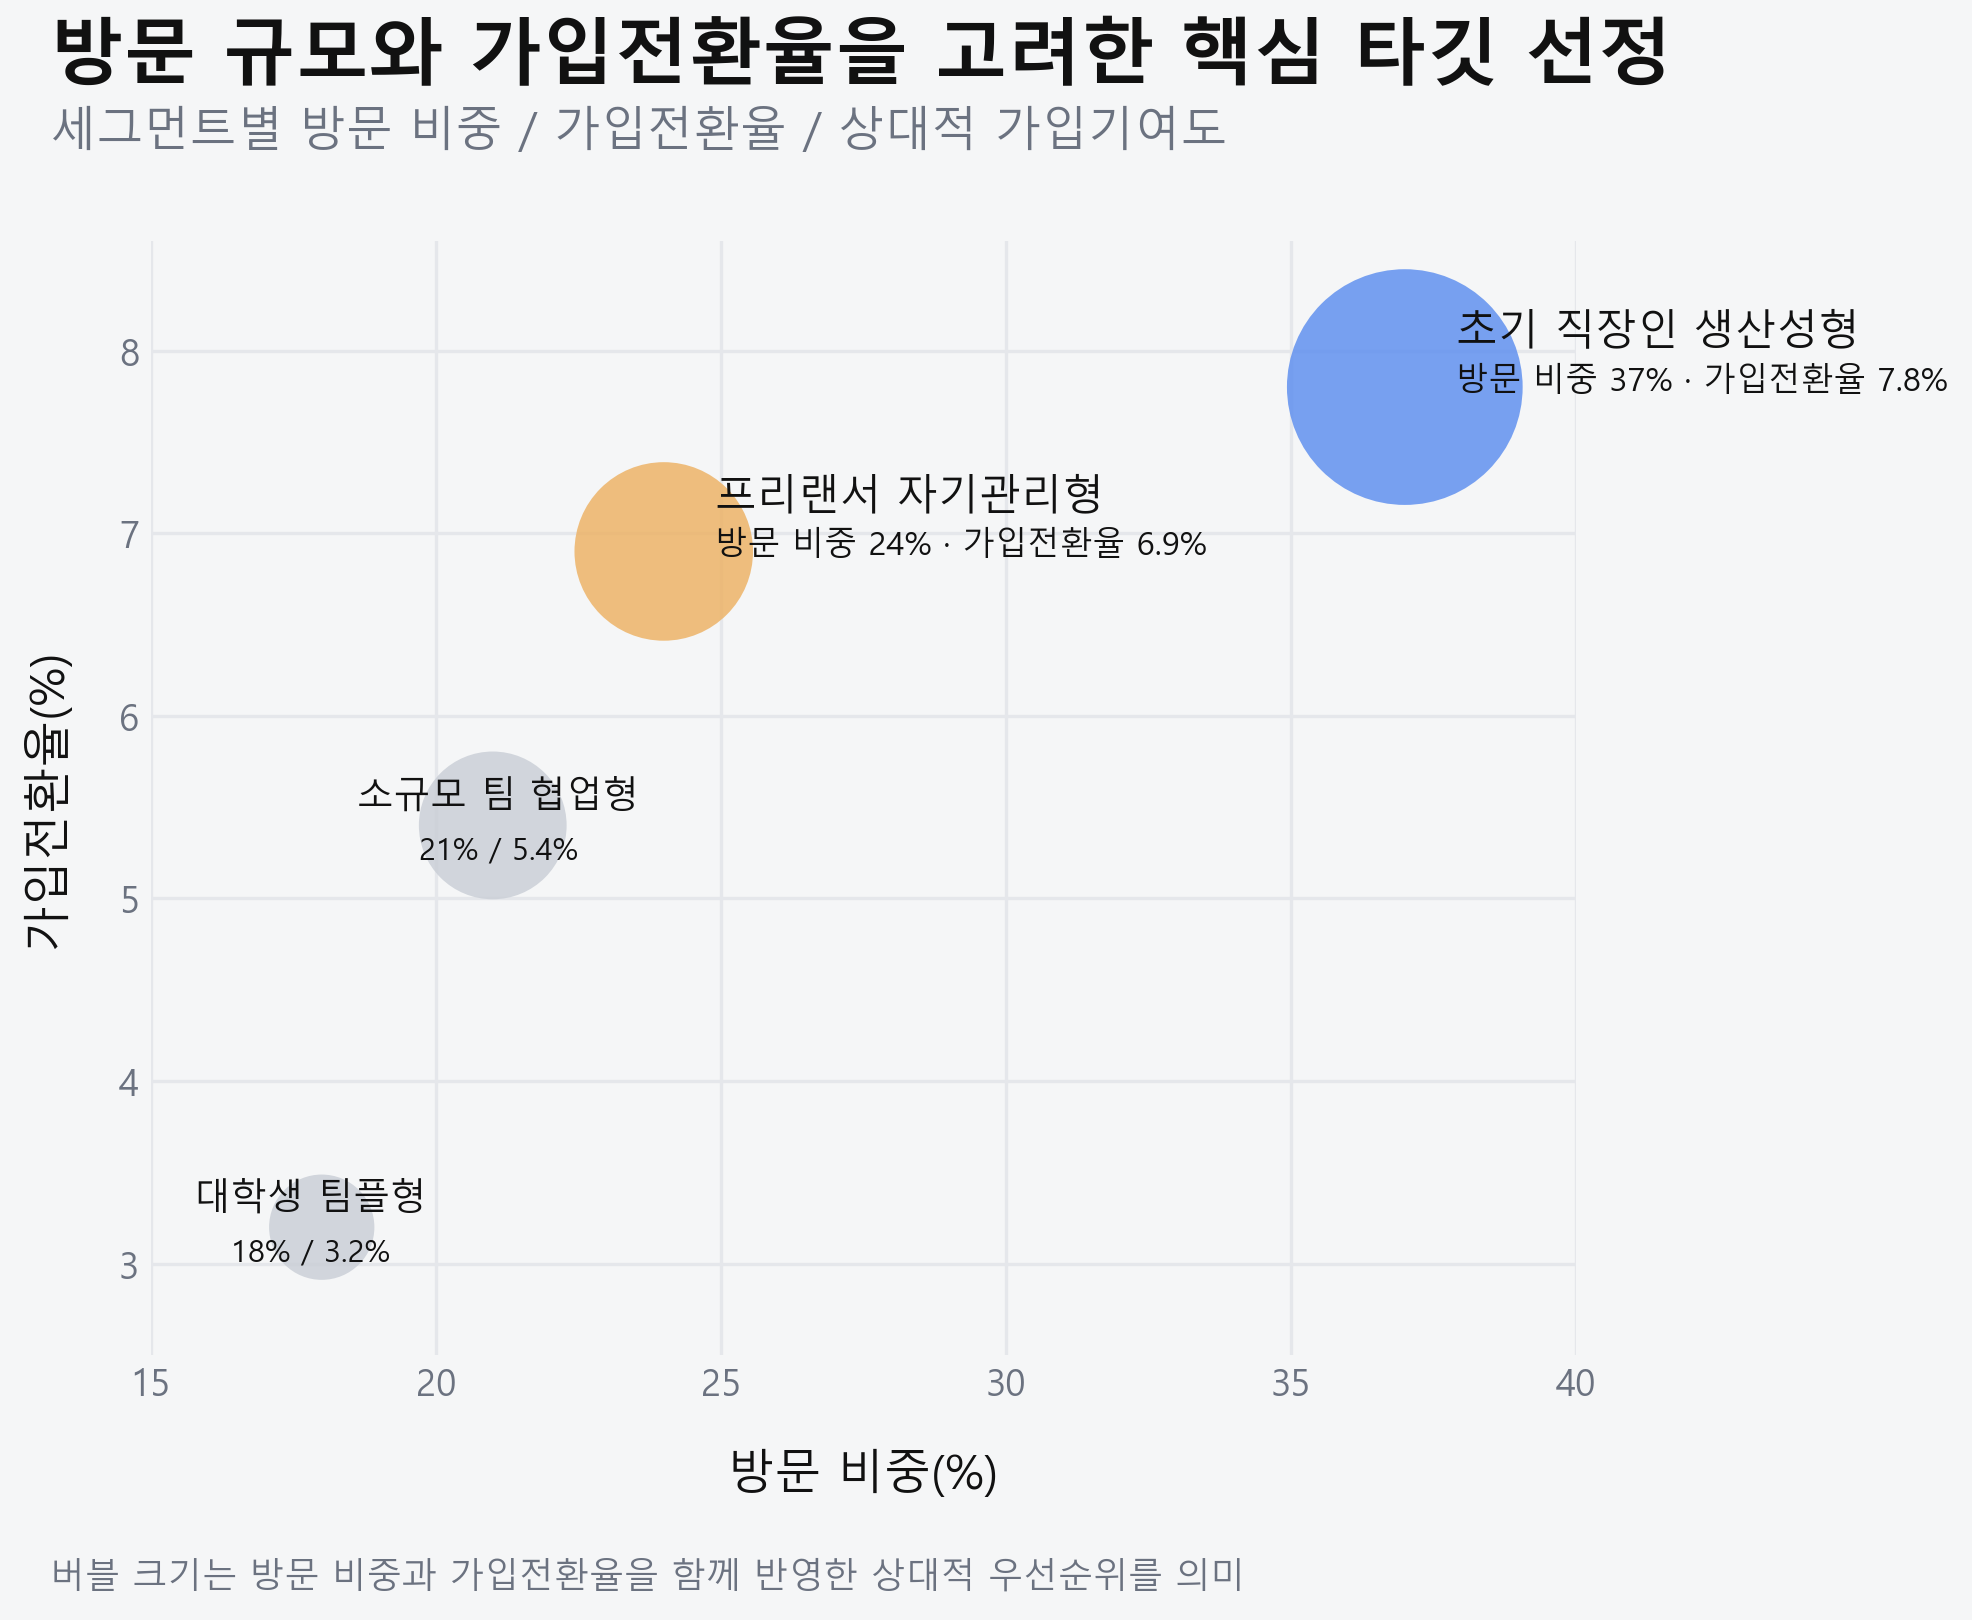

In [2]:
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import numpy as np

# =========================
# 0) 한글 폰트 자동 탐색
# =========================
preferred_fonts = [
    "AppleGothic",
    "Malgun Gothic",
    "NanumGothic",
    "NanumSquare",
    "Noto Sans CJK KR",
    "Noto Sans KR",
    "DejaVu Sans"
]

available_fonts = {f.name for f in fm.fontManager.ttflist}
FONT = next((f for f in preferred_fonts if f in available_fonts), "DejaVu Sans")

plt.rcParams["axes.unicode_minus"] = False

# =========================
# 1) 데이터
# =========================
segments = ["대학생 팀플형", "초기 직장인 생산성형", "프리랜서 자기관리형", "소규모 팀 협업형"]
visit_share = np.array([18, 37, 24, 21], dtype=float)      # 방문 비중(%)
conversion = np.array([3.2, 7.8, 6.9, 5.4], dtype=float)   # 가입전환율(%)

# 버블 크기용 상대 기여도
contribution = visit_share * conversion

# 버블 크기 정규화
sizes = (contribution / contribution.max()) * 5000

# =========================
# 2) 스타일
# =========================
BG = "#F5F6F7"
TEXT = "#111111"
SUBTEXT = "#6B7280"
GRID = "#E5E7EB"
BLUE = "#5B8DEF"
ORANGE = "#EDB162"
GRAY = "#C9CED6"

colors = [GRAY, BLUE, ORANGE, GRAY]

# =========================
# 3) 캔버스
# =========================
fig, ax = plt.subplots(figsize=(8.6, 7.2), facecolor=BG, dpi=240)
ax.set_facecolor(BG)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(True, axis="both", color=GRID, linewidth=1)
ax.set_axisbelow(True)

# =========================
# 4) 버블 차트
# =========================
ax.scatter(
    visit_share,
    conversion,
    s=sizes,
    c=colors,
    alpha=0.82,
    edgecolors="none",
    zorder=3
)

# =========================
# 5) 라벨
# - 글자색은 전부 검정
# - 세그먼트명 크게 / 숫자 작게 분리
# =========================
for x, y, label in zip(visit_share, conversion, segments):
    if label == "초기 직장인 생산성형":
        ax.text(
            x + 0.9, y + 0.18,
            f"{label}",
            fontsize=12.5,
            color=TEXT,
            fontfamily=FONT,
            ha="left",
            va="bottom"
        )
        ax.text(
            x + 0.9, y - 0.06,
            f"방문 비중 {x:.0f}% · 가입전환율 {y:.1f}%",
            fontsize=9.8,
            color=TEXT,
            fontfamily=FONT,
            ha="left",
            va="bottom"
        )

    elif label == "프리랜서 자기관리형":
        ax.text(
            x + 0.9, y + 0.18,
            f"{label}",
            fontsize=12.5,
            color=TEXT,
            fontfamily=FONT,
            ha="left",
            va="bottom"
        )
        ax.text(
            x + 0.9, y - 0.06,
            f"방문 비중 {x:.0f}% · 가입전환율 {y:.1f}%",
            fontsize=9.8,
            color=TEXT,
            fontfamily=FONT,
            ha="left",
            va="bottom"
        )

    elif label == "소규모 팀 협업형":
        ax.text(
            x + 0.1, y + 0.05,
            f"{label}",
            fontsize=11,
            color=TEXT,
            fontfamily=FONT,
            ha="center",
            va="bottom"
        )
        ax.text(
            x + 0.1, y - 0.06,
            f"{x:.0f}% / {y:.1f}%",
            fontsize=9.2,
            color=TEXT,
            fontfamily=FONT,
            ha="center",
            va="top"
        )

    else:  # 대학생 팀플형
        ax.text(
            x - 0.2, y + 0.05,
            f"{label}",
            fontsize=11,
            color=TEXT,
            fontfamily=FONT,
            ha="center",
            va="bottom"
        )
        ax.text(
            x - 0.2, y - 0.06,
            f"{x:.0f}% / {y:.1f}%",
            fontsize=9.2,
            color=TEXT,
            fontfamily=FONT,
            ha="center",
            va="top"
        )

# =========================
# 6) 축 / 범위
# =========================
ax.set_xlim(15, 40)
ax.set_ylim(2.5, 8.6)

ax.set_xticks([15, 20, 25, 30, 35, 40])
ax.set_yticks([3, 4, 5, 6, 7, 8])

ax.tick_params(axis="x", labelsize=11, colors=SUBTEXT, length=0)
ax.tick_params(axis="y", labelsize=11, colors=SUBTEXT, length=0)

for label in ax.get_xticklabels():
    label.set_fontfamily(FONT)
for label in ax.get_yticklabels():
    label.set_fontfamily(FONT)

ax.set_xlabel("방문 비중(%)", fontsize=14, color=TEXT, fontfamily=FONT, labelpad=14)
ax.set_ylabel("가입전환율(%)", fontsize=14, color=TEXT, fontfamily=FONT, labelpad=14)

# =========================
# 7) 제목
# =========================
fig.text(
    0.07, 0.965,
    "방문 규모와 가입전환율을 고려한 핵심 타깃 선정",
    ha="left", va="top",
    fontsize=22, fontweight="bold",
    color=TEXT, fontfamily=FONT
)
fig.text(
    0.07, 0.915,
    "세그먼트별 방문 비중 / 가입전환율 / 상대적 가입기여도",
    ha="left", va="top",
    fontsize=14,
    color=SUBTEXT, fontfamily=FONT
)

fig.text(
    0.07, 0.055,
    "버블 크기는 방문 비중과 가입전환율을 함께 반영한 상대적 우선순위를 의미",
    ha="left", va="bottom",
    fontsize=10.5,
    color=SUBTEXT, fontfamily=FONT
)

plt.tight_layout(rect=[0.04, 0.09, 1, 0.86])
plt.savefig("segment_targeting_bubble_chart_final.png", dpi=220, bbox_inches="tight", facecolor=BG)
plt.show()

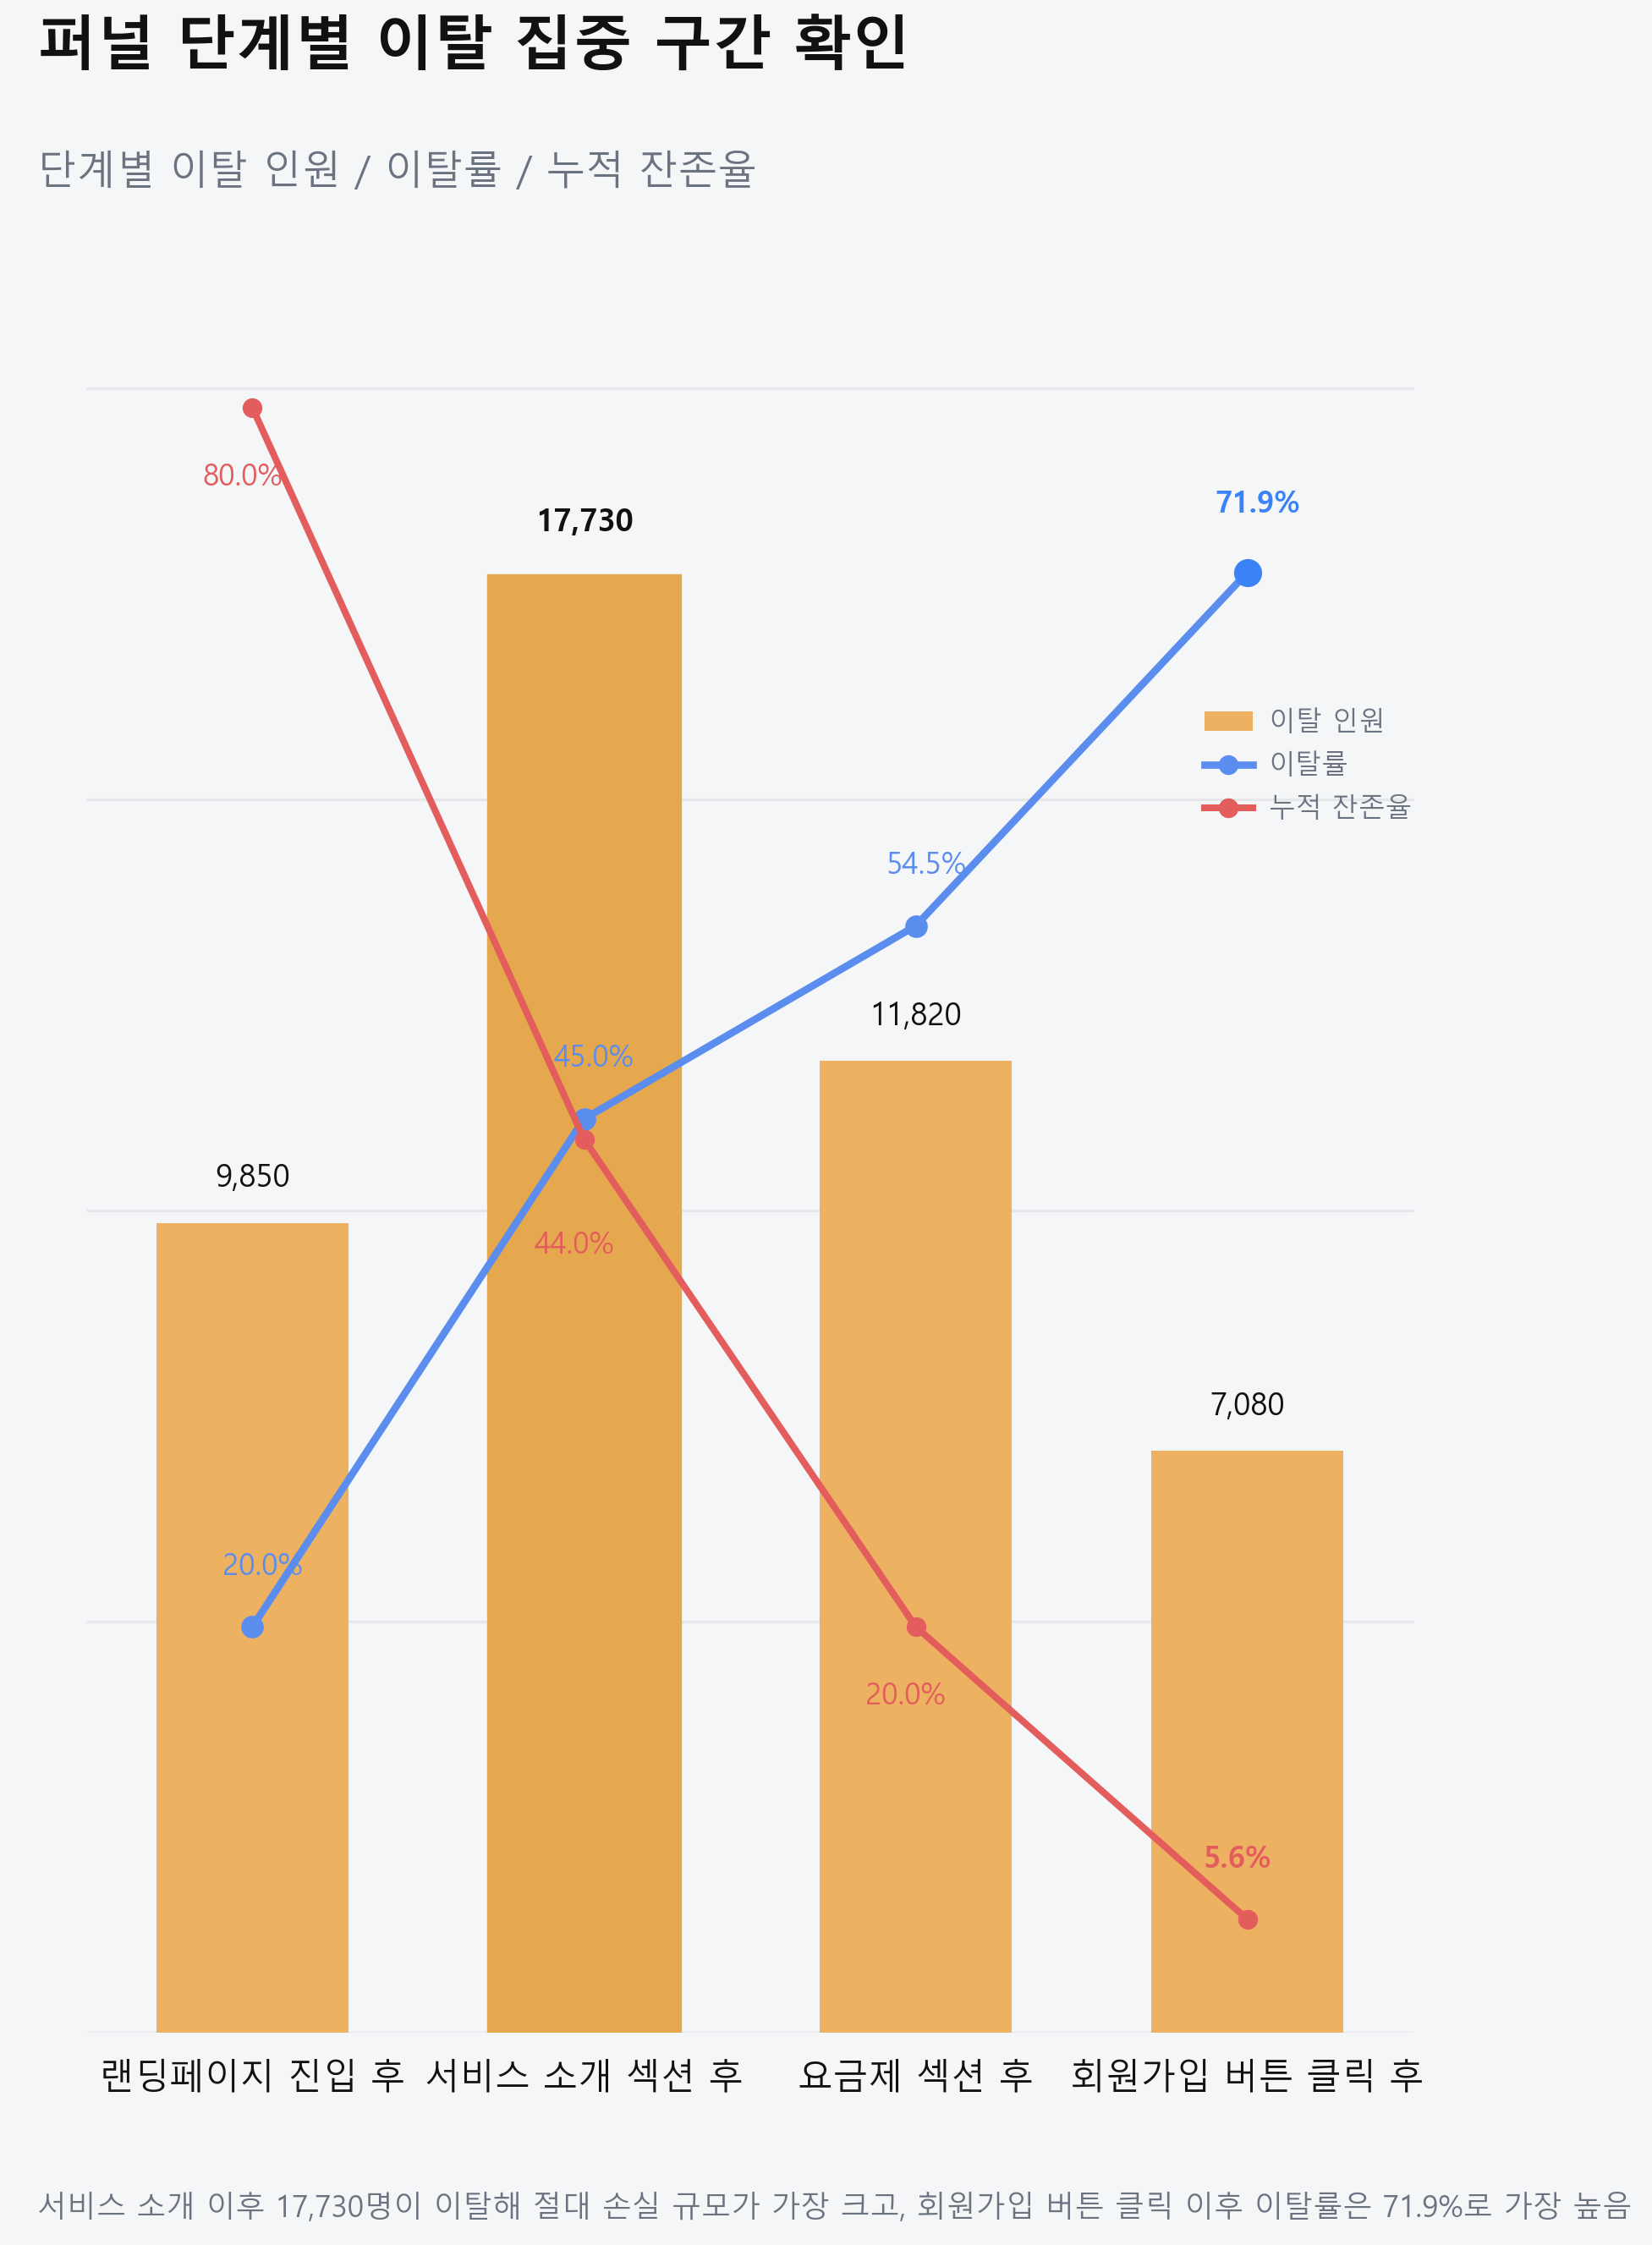

In [3]:
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np

# =========================
# 0) 한글 폰트 자동 탐색
# =========================
preferred_fonts = [
    "AppleGothic",
    "Malgun Gothic",
    "NanumGothic",
    "NanumSquare",
    "Noto Sans CJK KR",
    "Noto Sans KR",
    "DejaVu Sans"
]

available_fonts = {f.name for f in fm.fontManager.ttflist}
FONT = next((f for f in preferred_fonts if f in available_fonts), "DejaVu Sans")

plt.rcParams["axes.unicode_minus"] = False

# =========================
# 1) 데이터
# =========================
stages = [
    "랜딩페이지 진입 후",
    "서비스 소개 섹션 후",
    "요금제 섹션 후",
    "회원가입 버튼 클릭 후"
]

drop_counts = np.array([9850, 17730, 11820, 7080])   # 이탈 인원
drop_rates = np.array([20.0, 45.0, 54.5, 71.9])      # 이탈률
retention_rates = np.array([80.0, 44.0, 20.0, 5.6])  # 누적 잔존율

# =========================
# 2) 스타일
# =========================
BG = "#F5F6F7"
TEXT = "#111111"
SUBTEXT = "#6B7280"
GRID = "#E5E7EB"
BAR = "#EDB162"
BAR_HIGHLIGHT = "#E6A84E"
BLUE = "#5B8DEF"
RED = "#E35D5D"
BLUE_HIGHLIGHT = "#3B82F6"

fig, ax = plt.subplots(figsize=(7.8, 12.0), facecolor=BG, dpi=240)
ax.set_facecolor(BG)

for spine in ax.spines.values():
    spine.set_visible(False)

x = np.arange(len(stages))

# =========================
# 3) 막대: 이탈 인원
# =========================
bars = ax.bar(x, drop_counts, width=0.58, color=BAR, edgecolor="none", zorder=2)
bars[1].set_color(BAR_HIGHLIGHT)  # 17,730명 구간 강조

for i, (rect, val) in enumerate(zip(bars, drop_counts)):
    y_offset = 350
    fw = "normal"

    if i == 1:
        fw = "bold"
        y_offset = 450

    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + y_offset,
        f"{val:,}",
        ha="center",
        va="bottom",
        fontsize=11,
        color=TEXT,
        fontfamily=FONT,
        fontweight=fw
    )

# 가이드라인
for y in [0, 5000, 10000, 15000, 20000]:
    ax.hlines(y, -0.5, len(x) - 0.5, colors=GRID, lw=1, zorder=0)

ax.set_ylim(0, 21000)
ax.set_yticks([])

# =========================
# 4) 보조축: 이탈률 + 누적 잔존율
# =========================
ax2 = ax.twinx()
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.set_facecolor("none")

# 이탈률 라인
ax2.plot(
    x, drop_rates,
    color=BLUE, lw=2.6, marker="o", markersize=7, zorder=4
)
ax2.scatter([x[3]], [drop_rates[3]], color=BLUE_HIGHLIGHT, s=80, zorder=5)

# 누적 잔존율 라인
ax2.plot(
    x, retention_rates,
    color=RED, lw=2.4, marker="o", markersize=6, zorder=4
)

# 이탈률 라벨
for i, (xi, rate) in enumerate(zip(x, drop_rates)):
    color = BLUE
    fw = "normal"
    dy = 2.2

    if i == 3:
        color = BLUE_HIGHLIGHT
        fw = "bold"
        dy = 2.6

    ax2.text(
        xi + 0.03,
        rate + dy,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10.5,
        color=color,
        fontfamily=FONT,
        fontweight=fw
    )

# 누적 잔존율 라벨
retention_label_offsets = [-4.2, -6.0, -4.2, 2.2]

for i, (xi, rate) in enumerate(zip(x, retention_rates)):
    fw = "bold" if i == 3 else "normal"
    dy = retention_label_offsets[i]

    ax2.text(
        xi - 0.03,
        rate + dy,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10.5,
        color=RED,
        fontfamily=FONT,
        fontweight=fw
    )
ax2.set_ylim(0, 85)
ax2.set_yticks([])

# =========================
# 5) x축
# =========================
ax.set_xticks(x)
ax.set_xticklabels(
    stages,
    fontsize=12.5,
    color=TEXT,
    fontfamily=FONT
)
ax.tick_params(axis="x", length=0, pad=10)

# =========================
# 6) 제목
# =========================
fig.text(
    0.07, 0.965,
    "퍼널 단계별 이탈 집중 구간 확인",
    ha="left", va="top",
    fontsize=21,
    fontweight="bold",
    color=TEXT,
    fontfamily=FONT
)
fig.text(
    0.07, 0.91,
    "단계별 이탈 인원 / 이탈률 / 누적 잔존율",
    ha="left", va="top",
    fontsize=14,
    color=SUBTEXT,
    fontfamily=FONT
)

# =========================
# 7) 작은 범례
# =========================
legend_elements = [
    Patch(facecolor=BAR, edgecolor="none", label="이탈 인원"),
    Line2D([0], [0], color=BLUE, lw=2.6, marker="o", markersize=6, label="이탈률"),
    Line2D([0], [0], color=RED, lw=2.4, marker="o", markersize=6, label="누적 잔존율")
]

leg = ax.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(0.97, 0.78),
    frameon=False,
    fontsize=9.5,
    handlelength=1.8,
    handletextpad=0.6,
    labelspacing=0.6
)

for text in leg.get_texts():
    text.set_fontfamily(FONT)
    text.set_color(SUBTEXT)

# =========================
# 8) 하단 해석 문장
# =========================
fig.text(
    0.07, 0.06,
    "서비스 소개 이후 17,730명이 이탈해 절대 손실 규모가 가장 크고, 회원가입 버튼 클릭 이후 이탈률은 71.9%로 가장 높음",
    ha="left", va="bottom",
    fontsize=10.5,
    color=SUBTEXT,
    fontfamily=FONT
)

plt.tight_layout(rect=[0.04, 0.10, 1, 0.86])
plt.savefig("funnel_loss_combo_chart_with_retention.png", dpi=220, bbox_inches="tight", facecolor=BG)
plt.show()

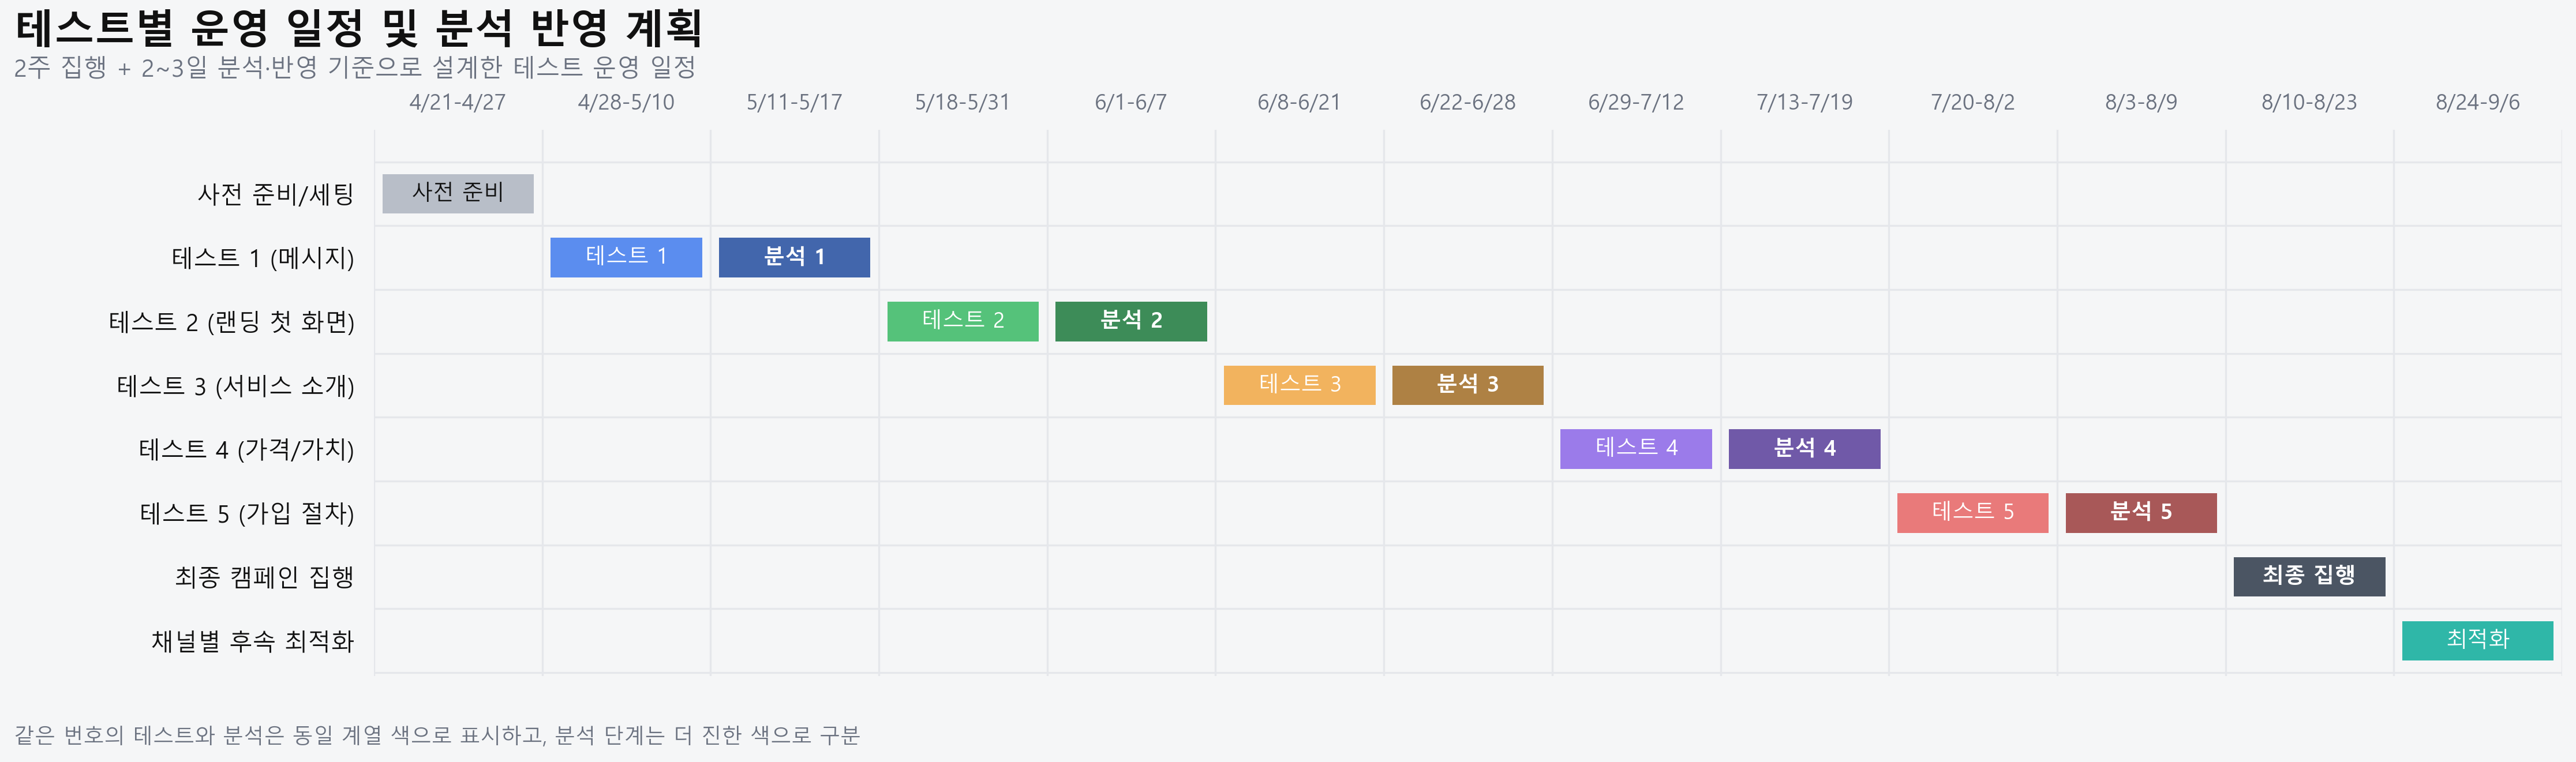

In [58]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import font_manager as fm
import matplotlib.colors as mcolors
import numpy as np

# =========================
# 0) 한글 폰트 자동 탐색
# =========================
preferred_fonts = [
    "AppleGothic",
    "Malgun Gothic",
    "NanumGothic",
    "NanumSquare",
    "Noto Sans CJK KR",
    "Noto Sans KR",
    "DejaVu Sans"
]

available_fonts = {f.name for f in fm.fontManager.ttflist}
FONT = next((f for f in preferred_fonts if f in available_fonts), "DejaVu Sans")

plt.rcParams["axes.unicode_minus"] = False

# =========================
# 1) 스타일
# =========================
BG = "#F5F6F7"
TEXT = "#111111"
SUBTEXT = "#6B7280"
GRID = "#E5E7EB"

TEST_COLORS = {
    1: "#5B8DEF",   # 파랑
    2: "#55C27A",   # 초록
    3: "#F2B35E",   # 주황
    4: "#9B7BEA",   # 보라
    5: "#E97A7A",   # 빨강
    "final": "#4B5563",
    "opt": "#2FB7A8",
    "prep": "#B8BEC8"
}

def darken(color, factor=0.72):
    rgb = np.array(mcolors.to_rgb(color))
    return mcolors.to_hex(rgb * factor)

# =========================
# 2) 기간 축
# =========================
periods = [
    "4/21-4/27",
    "4/28-5/10",
    "5/11-5/17",
    "5/18-5/31",
    "6/1-6/7",
    "6/8-6/21",
    "6/22-6/28",
    "6/29-7/12",
    "7/13-7/19",
    "7/20-8/2",
    "8/3-8/9",
    "8/10-8/23",
    "8/24-9/6"
]

# =========================
# 3) 행 데이터
# =========================
rows = [
    {
        "name": "사전 준비/세팅",
        "segments": [
            {"start": 0, "width": 1, "kind": "prep", "label": "사전 준비"}
        ]
    },
    {
        "name": "테스트 1 (메시지)",
        "segments": [
            {"start": 1, "width": 1, "kind": "test", "test_id": 1, "label": "테스트 1"},
            {"start": 2, "width": 1, "kind": "analysis", "test_id": 1, "label": "분석 1"},
        ]
    },
    {
        "name": "테스트 2 (랜딩 첫 화면)",
        "segments": [
            {"start": 3, "width": 1, "kind": "test", "test_id": 2, "label": "테스트 2"},
            {"start": 4, "width": 1, "kind": "analysis", "test_id": 2, "label": "분석 2"},
        ]
    },
    {
        "name": "테스트 3 (서비스 소개)",
        "segments": [
            {"start": 5, "width": 1, "kind": "test", "test_id": 3, "label": "테스트 3"},
            {"start": 6, "width": 1, "kind": "analysis", "test_id": 3, "label": "분석 3"},
        ]
    },
    {
        "name": "테스트 4 (가격/가치)",
        "segments": [
            {"start": 7, "width": 1, "kind": "test", "test_id": 4, "label": "테스트 4"},
            {"start": 8, "width": 1, "kind": "analysis", "test_id": 4, "label": "분석 4"},
        ]
    },
    {
        "name": "테스트 5 (가입 절차)",
        "segments": [
            {"start": 9, "width": 1, "kind": "test", "test_id": 5, "label": "테스트 5"},
            {"start": 10, "width": 1, "kind": "analysis", "test_id": 5, "label": "분석 5"},
        ]
    },
    {
        "name": "최종 캠페인 집행",
        "segments": [
            {"start": 11, "width": 1, "kind": "final", "label": "최종 집행"}
        ]
    },
    {
        "name": "채널별 후속 최적화",
        "segments": [
            {"start": 12, "width": 1, "kind": "opt", "label": "최적화"}
        ]
    },
]

# =========================
# 4) 캔버스
# =========================
fig, ax = plt.subplots(figsize=(20, 5.8), facecolor=BG, dpi=240)
ax.set_facecolor(BG)

for spine in ax.spines.values():
    spine.set_visible(False)

n_rows = len(rows)
n_cols = len(periods)

# 배경 그리드
for x in range(n_cols + 1):
    ax.axvline(x, color=GRID, lw=1, zorder=0)

for y in np.arange(-0.5, n_rows + 0.5, 1):
    ax.axhline(y, color=GRID, lw=1, zorder=0)

bar_h = 0.62

# =========================
# 5) 막대 그리기
# =========================
for y, row in enumerate(rows):
    for seg in row["segments"]:
        kind = seg["kind"]

        if kind == "prep":
            color = TEST_COLORS["prep"]
        elif kind == "final":
            color = TEST_COLORS["final"]
        elif kind == "opt":
            color = TEST_COLORS["opt"]
        elif kind == "test":
            color = TEST_COLORS[seg["test_id"]]
        elif kind == "analysis":
            color = darken(TEST_COLORS[seg["test_id"]], 0.72)

        rect = Rectangle(
            (seg["start"] + 0.05, y - bar_h / 2),
            seg["width"] - 0.10,
            bar_h,
            facecolor=color,
            edgecolor="none",
            zorder=3
        )
        ax.add_patch(rect)

        ax.text(
            seg["start"] + seg["width"] / 2,
            y,
            seg["label"],
            ha="center",
            va="center",
            fontsize=11.2,
            color="white" if kind in ["test", "analysis", "final", "opt"] else TEXT,
            fontfamily=FONT,
            fontweight="bold" if kind in ["analysis", "final"] else "normal",
            zorder=4
        )

# =========================
# 6) 축 설정
# - 날짜를 위로 배치
# =========================
ax.set_xlim(0, n_cols)
ax.set_ylim(-1.0, n_rows - 0.45)
ax.invert_yaxis()

ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(periods, fontsize=11.2, color=SUBTEXT, fontfamily=FONT)
ax.tick_params(
    axis="x",
    top=True, labeltop=True,
    bottom=False, labelbottom=False,
    length=0, pad=8
)

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels([r["name"] for r in rows], fontsize=12.2, color=TEXT, fontfamily=FONT)
ax.tick_params(axis="y", length=0, pad=10)

# =========================
# 7) 제목
# =========================
fig.text(
    0.05, 0.965,
    "테스트별 운영 일정 및 분석 반영 계획",
    ha="left", va="top",
    fontsize=21,
    fontweight="bold",
    color=TEXT,
    fontfamily=FONT
)
fig.text(
    0.05, 0.91,
    "2주 집행 + 2~3일 분석·반영 기준으로 설계한 테스트 운영 일정",
    ha="left", va="top",
    fontsize=12.5,
    color=SUBTEXT,
    fontfamily=FONT
)

# =========================
# 8) 하단 주석
# =========================
fig.text(
    0.05, 0.05,
    "같은 번호의 테스트와 분석은 동일 계열 색으로 표시하고, 분석 단계는 더 진한 색으로 구분",
    ha="left",
    va="bottom",
    fontsize=10.8,
    color=SUBTEXT,
    fontfamily=FONT
)

# 여백을 타이트하게
ax.set_position([0.18, 0.14, 0.79, 0.68])

plt.savefig("gantt_test_schedule_tight_topdates.png", dpi=240, bbox_inches="tight", facecolor=BG)
plt.show()

채널별 주요 지표 표


채널,가입전환율,방문수,CAC
제휴/추천,12.0%,"2,250","11,000원"
콘텐츠,9.0%,"5,400","15,000원"
검색,6.0%,"17,500","28,000원"
SNS,4.0%,"18,200","41,000원"
유튜브,4.0%,"5,900","48,000원"


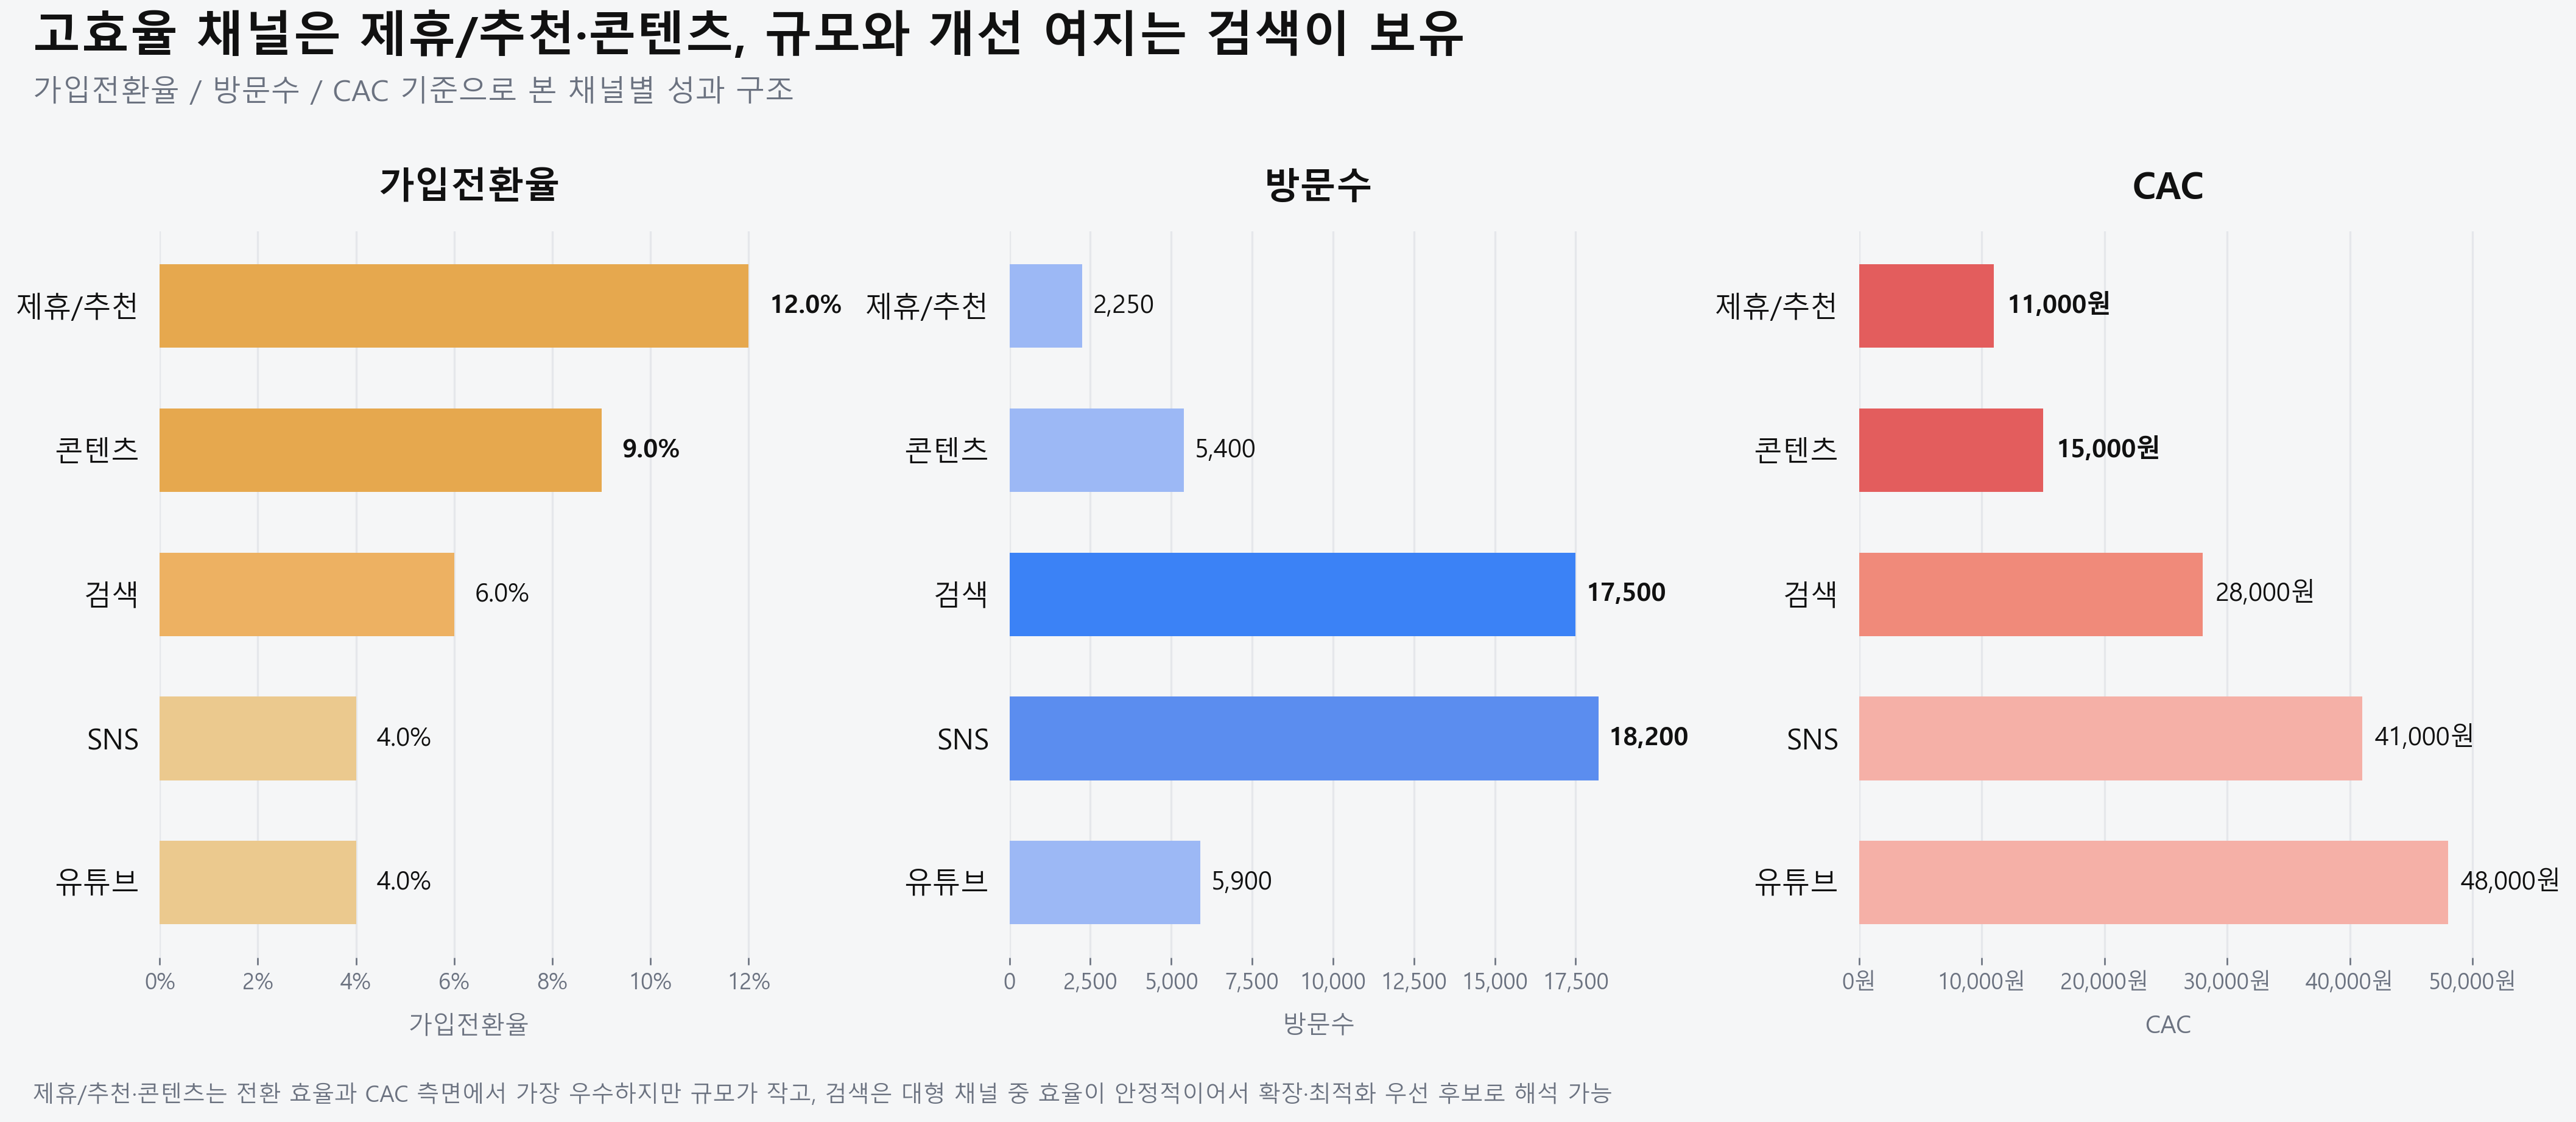

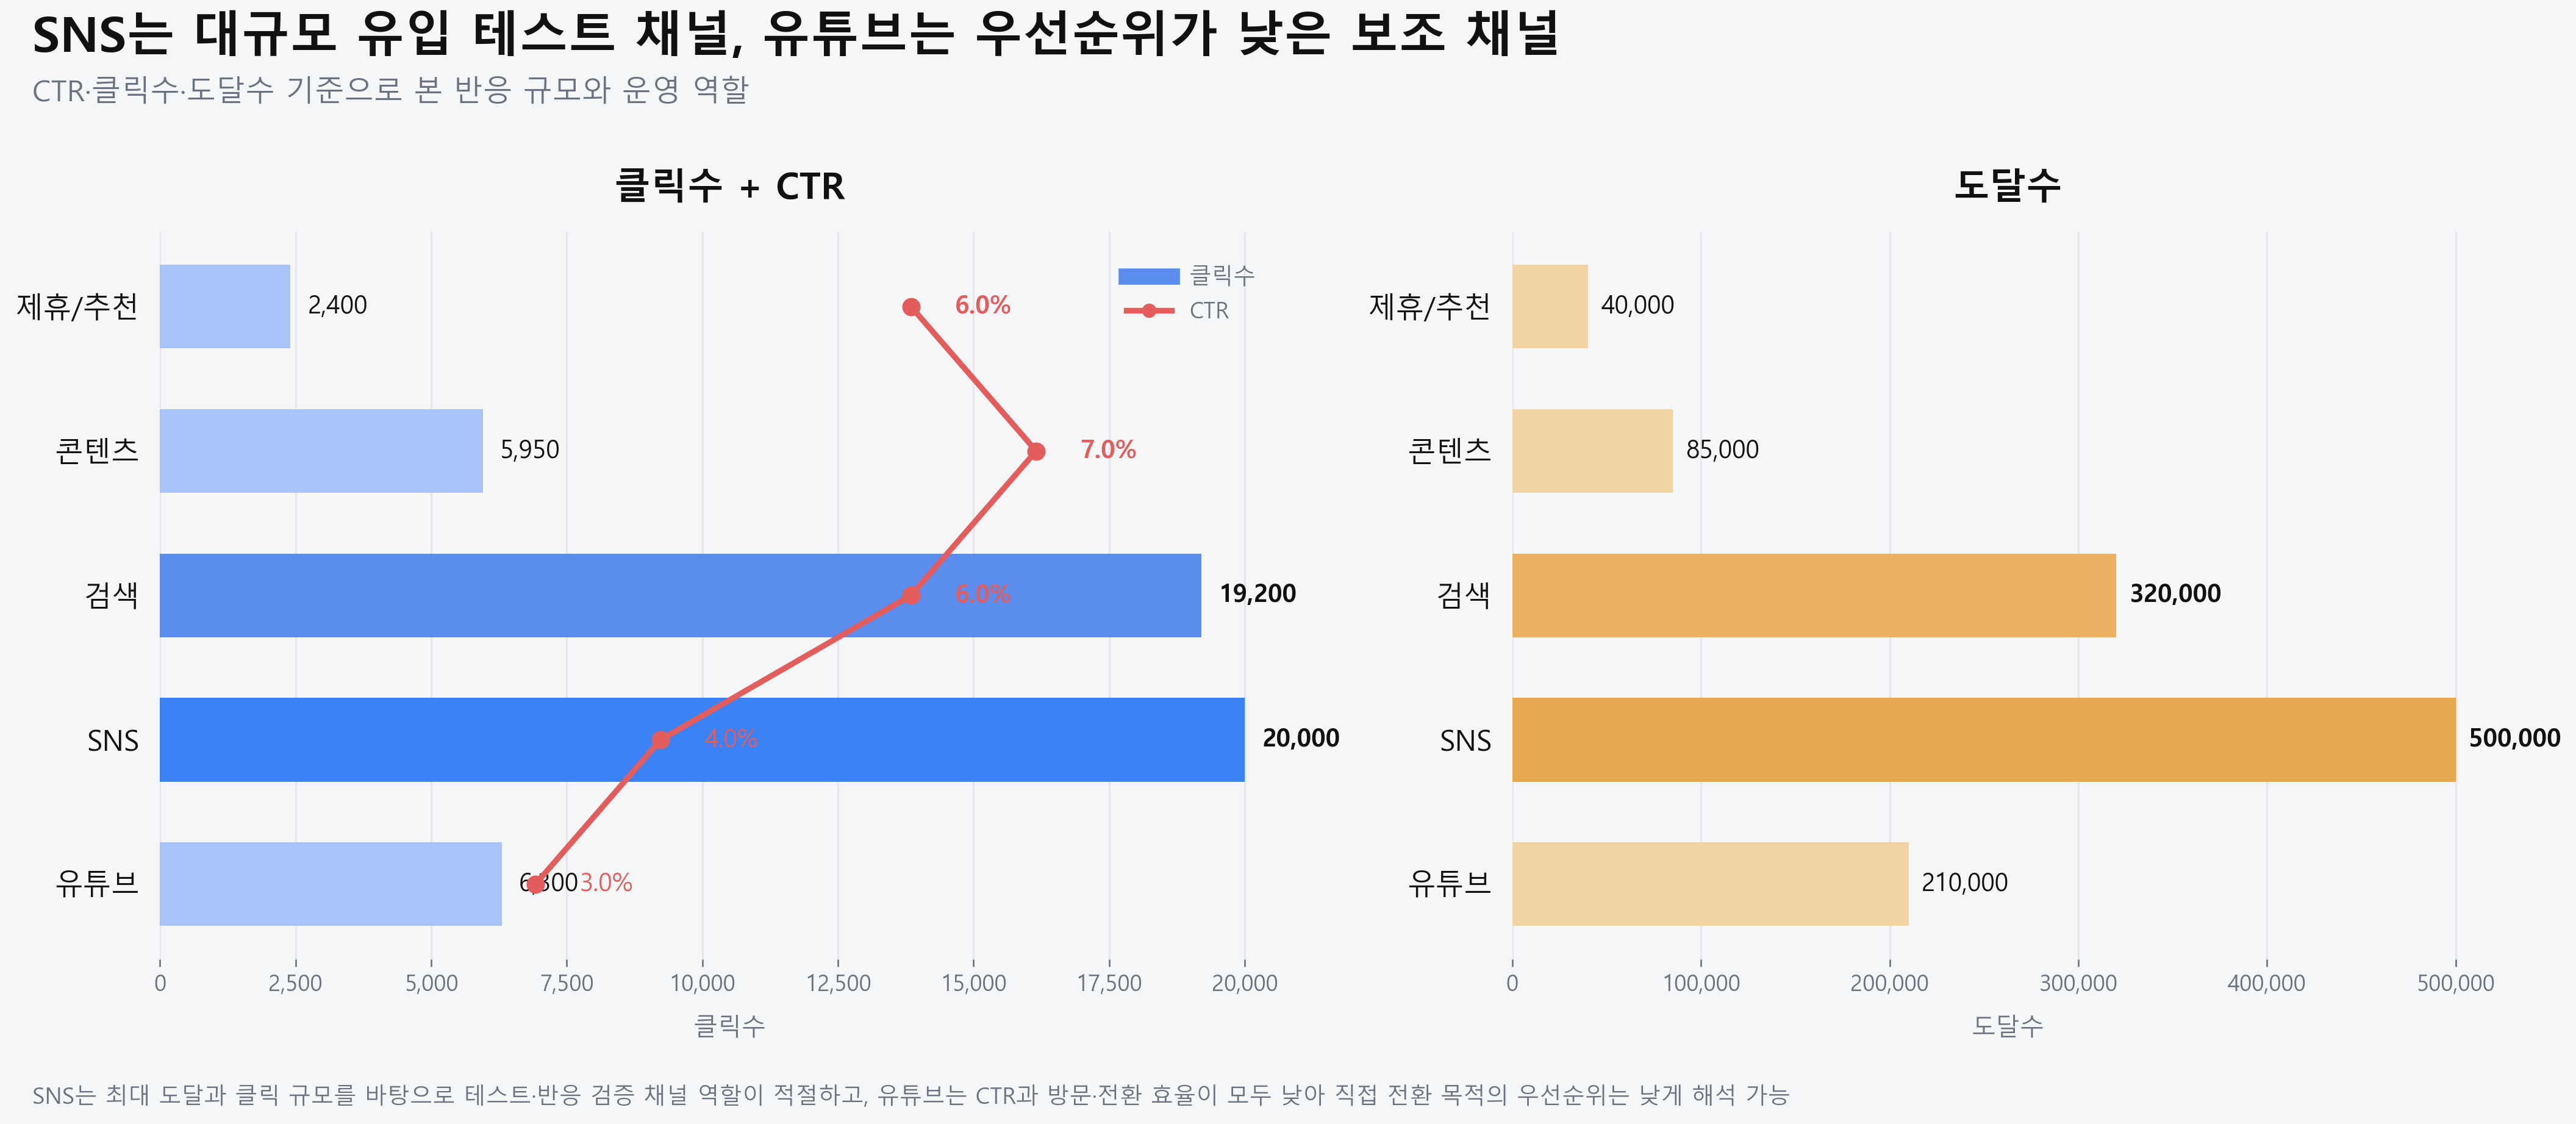

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
import numpy as np

# =========================================================
# 0) 한글 폰트 자동 탐색
# =========================================================
preferred_fonts = [
    "AppleGothic",
    "Malgun Gothic",
    "NanumGothic",
    "NanumSquare",
    "Noto Sans CJK KR",
    "Noto Sans KR",
    "DejaVu Sans"
]
available_fonts = {f.name for f in fm.fontManager.ttflist}
FONT = next((f for f in preferred_fonts if f in available_fonts), "DejaVu Sans")

plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = False

# =========================================================
# 1) Raw data
# =========================================================
channel_rows = [
    {"ch": "search",   "impression": 320000, "click_counts": 19200, "ctr": 0.06, "visit_counts": 17500, "sign": 1050, "sign_rate": 0.06, "cac": 28000},
    {"ch": "sns",      "impression": 500000, "click_counts": 20000, "ctr": 0.04, "visit_counts": 18200, "sign": 728,  "sign_rate": 0.04, "cac": 41000},
    {"ch": "youtube",  "impression": 210000, "click_counts": 6300,  "ctr": 0.03, "visit_counts": 5900,  "sign": 236,  "sign_rate": 0.04, "cac": 48000},
    {"ch": "content",  "impression": 85000,  "click_counts": 5950,  "ctr": 0.07, "visit_counts": 5400,  "sign": 486,  "sign_rate": 0.09, "cac": 15000},
    {"ch": "referral/recommend", "impression": 40000,  "click_counts": 2400,  "ctr": 0.06, "visit_counts": 2250,  "sign": 270,  "sign_rate": 0.12, "cac": 11000},
]

df = pd.DataFrame(channel_rows)

# =========================================================
# 2) Korean labels
# =========================================================
channel_name_map = {
    "search": "검색",
    "sns": "SNS",
    "youtube": "유튜브",
    "content": "콘텐츠",
    "referral/recommend": "제휴/추천"
}

df["채널"] = df["ch"].map(channel_name_map)
df["가입전환율"] = df["sign_rate"] * 100
df["방문수"] = df["visit_counts"]
df["CAC"] = df["cac"]
df["CTR"] = df["ctr"] * 100
df["클릭수"] = df["click_counts"]
df["도달수"] = df["impression"]

# 전환율 중심 정렬
base_df = df[["채널", "가입전환율", "방문수", "CAC", "CTR", "클릭수", "도달수"]].copy()
base_df = base_df.sort_values(
    by=["가입전환율", "방문수"],
    ascending=[False, False]
).reset_index(drop=True)

# =========================================================
# 3) 공통 스타일
# =========================================================
BG = "#F5F6F7"
TEXT = "#111111"
SUBTEXT = "#6B7280"
GRID = "#E5E7EB"

BAR_MAIN = "#EDB162"        # 메인 바
BAR_HIGHLIGHT = "#E6A84E"   # 강조 바
BLUE = "#5B8DEF"            # 보조 선/바
RED = "#E35D5D"             # 보조 선/바
BLUE_HIGHLIGHT = "#3B82F6"
TEAL = "#4FAE9D"

def style_axis(ax):
    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis="x", color=GRID, lw=1, zorder=0)
    ax.tick_params(axis="x", colors=SUBTEXT, labelsize=11)
    ax.tick_params(axis="y", colors=TEXT, labelsize=14, length=0, pad=10)

# =========================================================
# 4) 표
# =========================================================
table_df = base_df[["채널", "가입전환율", "방문수", "CAC"]].copy()
table_df["가입전환율"] = table_df["가입전환율"].map(lambda x: f"{x:.1f}%")
table_df["방문수"] = table_df["방문수"].map(lambda x: f"{x:,}")
table_df["CAC"] = table_df["CAC"].map(lambda x: f"{x:,}원")

print("채널별 주요 지표 표")

display(
    table_df.style
    .hide(axis="index")
    .set_caption("채널별 전환 효율·규모·비용 요약")
    .set_properties(**{
        "text-align": "center",
        "padding": "9px",
        "font-size": "13px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#111111"),
                ("color", "white"),
                ("font-size", "13px"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("color", "#111111"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #E5E7EB")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "10px 0")
            ]
        }
    ])
)

# =========================================================
# 5) 그래프 1: 가입전환율 / 방문수 / CAC
#    기존 비율 유지: figsize=(23, 8)
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 8), facecolor=BG, dpi=240)
fig.patch.set_facecolor(BG)

# 5-1) 가입전환율
ax = axes[0]
style_axis(ax)

conv_colors = []
for ch in base_df["채널"]:
    if ch in ["제휴/추천", "콘텐츠"]:
        conv_colors.append(BAR_HIGHLIGHT)
    elif ch == "검색":
        conv_colors.append(BAR_MAIN)
    else:
        conv_colors.append("#EBC98E")

bars = ax.barh(base_df["채널"], base_df["가입전환율"], color=conv_colors, height=0.58, zorder=2)
ax.invert_yaxis()
ax.set_title("가입전환율", fontsize=18, fontweight="bold", color=TEXT, pad=16, fontfamily=FONT)
ax.set_xlabel("가입전환율", fontsize=12, color=SUBTEXT, labelpad=10, fontfamily=FONT)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0f}%"))

for i, b in enumerate(bars):
    value = b.get_width()
    fw = "bold" if base_df.loc[i, "채널"] in ["제휴/추천", "콘텐츠"] else "normal"
    ax.text(
        value + base_df["가입전환율"].max() * 0.035,
        b.get_y() + b.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=12.5,
        color=TEXT,
        fontfamily=FONT,
        fontweight=fw
    )

# 5-2) 방문수
ax = axes[1]
style_axis(ax)

visit_colors = []
for ch in base_df["채널"]:
    if ch == "검색":
        visit_colors.append(BLUE_HIGHLIGHT)
    elif ch == "SNS":
        visit_colors.append(BLUE)
    else:
        visit_colors.append("#9CB8F5")

bars = ax.barh(base_df["채널"], base_df["방문수"], color=visit_colors, height=0.58, zorder=2)
ax.invert_yaxis()
ax.set_title("방문수", fontsize=18, fontweight="bold", color=TEXT, pad=16, fontfamily=FONT)
ax.set_xlabel("방문수", fontsize=12, color=SUBTEXT, labelpad=10, fontfamily=FONT)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))

for i, b in enumerate(bars):
    value = b.get_width()
    fw = "bold" if base_df.loc[i, "채널"] in ["검색", "SNS"] else "normal"
    ax.text(
        value + base_df["방문수"].max() * 0.018,
        b.get_y() + b.get_height() / 2,
        f"{int(value):,}",
        va="center",
        fontsize=12.5,
        color=TEXT,
        fontfamily=FONT,
        fontweight=fw,
    )

# 5-3) CAC
ax = axes[2]
style_axis(ax)

cac_colors = []
for ch in base_df["채널"]:
    if ch in ["제휴/추천", "콘텐츠"]:
        cac_colors.append(RED)
    elif ch == "검색":
        cac_colors.append("#F08A7A")
    else:
        cac_colors.append("#F5B0A7")

bars = ax.barh(base_df["채널"], base_df["CAC"], color=cac_colors, height=0.58, zorder=2)
ax.invert_yaxis()
ax.set_title("CAC", fontsize=18, fontweight="bold", color=TEXT, pad=16, fontfamily=FONT)
ax.set_xlabel("CAC", fontsize=12, color=SUBTEXT, labelpad=10, fontfamily=FONT)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}원"))

for i, b in enumerate(bars):
    value = b.get_width()
    fw = "bold" if base_df.loc[i, "채널"] in ["제휴/추천", "콘텐츠"] else "normal"
    ax.text(
        value + base_df["CAC"].max() * 0.022,
        b.get_y() + b.get_height() / 2,
        f"{int(value):,}원",
        va="center",
        fontsize=12.5,
        color=TEXT,
        fontfamily=FONT,
        fontweight=fw
    )

fig.text(
    0.03, 0.975,
    "고효율 채널은 제휴/추천·콘텐츠, 규모와 개선 여지는 검색이 보유",
    ha="left", va="top",
    fontsize=24, fontweight="bold", color=TEXT, fontfamily=FONT
)
fig.text(
    0.03, 0.920,
    "가입전환율 / 방문수 / CAC 기준으로 본 채널별 성과 구조",
    ha="left", va="top",
    fontsize=14.5, color=SUBTEXT, fontfamily=FONT
)

fig.text(
    0.03, 0.04,
    "제휴/추천·콘텐츠는 전환 효율과 CAC 측면에서 가장 우수하지만 규모가 작고, 검색은 대형 채널 중 효율이 안정적이어서 확장·최적화 우선 후보로 해석 가능",
    ha="left", va="bottom",
    fontsize=11.2, color=SUBTEXT, fontfamily=FONT
)

plt.tight_layout(rect=[0.015, 0.08, 1, 0.86])
plt.show()


# =========================================================
# 6) 그래프 2: CTR+클릭수 / 도달수
#    기존 비율 유지: figsize=(21, 8)
# =========================================================
plot_df = base_df.copy()

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 8),
    gridspec_kw={"width_ratios": [1.15, 1]},
    facecolor=BG, dpi=240
)
fig.patch.set_facecolor(BG)

for ax in axes:
    style_axis(ax)

# 6-1) CTR + 클릭수
ax = axes[0]
y = np.arange(len(plot_df))

click_colors = []
for ch in plot_df["채널"]:
    if ch == "SNS":
        click_colors.append(BLUE_HIGHLIGHT)
    elif ch == "검색":
        click_colors.append(BLUE)
    else:
        click_colors.append("#A9C2F8")

bars = ax.barh(
    y,
    plot_df["클릭수"],
    color=click_colors,
    height=0.58,
    zorder=2
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["채널"], fontsize=14, color=TEXT, fontfamily=FONT)
ax.invert_yaxis()
ax.set_title("클릭수 + CTR", fontsize=18, fontweight="bold", color=TEXT, pad=16, fontfamily=FONT)
ax.set_xlabel("클릭수", fontsize=12, color=SUBTEXT, labelpad=10, fontfamily=FONT)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))

for i, b in enumerate(bars):
    value = b.get_width()
    fw = "bold" if plot_df.loc[i, "채널"] in ["SNS", "검색"] else "normal"
    ax.text(
        value + plot_df["클릭수"].max() * 0.016,
        b.get_y() + b.get_height() / 2,
        f"{int(value):,}",
        va="center",
        fontsize=12.2,
        color=TEXT,
        fontfamily=FONT,
        fontweight=fw
    )

ax_top = ax.twiny()
for spine in ax_top.spines.values():
    spine.set_visible(False)
ax_top.set_facecolor("none")
ax_top.set_xlim(0, max(plot_df["CTR"]) * 1.30)
ax_top.set_xticks([])

ax_top.plot(
    plot_df["CTR"],
    y,
    color=RED,
    marker="o",
    linewidth=2.8,
    markersize=8,
    zorder=4
)

ctr_dx = {
    "제휴/추천": 0.35,
    "콘텐츠": 0.35,
    "검색": 0.35,
    "SNS": 0.35,
    "유튜브": 0.35
}
for i, (xv, yi) in enumerate(zip(plot_df["CTR"], y)):
    fw = "bold" if plot_df.loc[i, "채널"] in ["검색", "제휴/추천", "콘텐츠"] else "normal"
    ax_top.text(
        xv + ctr_dx[plot_df.loc[i, "채널"]],
        yi,
        f"{xv:.1f}%",
        va="center",
        fontsize=12.2,
        color=RED,
        fontfamily=FONT,
        fontweight=fw
    )

legend_items = [
    Line2D([0], [0], color=BLUE, lw=8),
    Line2D([0], [0], color=RED, marker="o", lw=2.8)
]
leg = ax.legend(
    legend_items,
    ["클릭수", "CTR"],
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=False,
    fontsize=11
)
for text in leg.get_texts():
    text.set_fontfamily(FONT)
    text.set_color(SUBTEXT)

# 6-2) 도달수
ax = axes[1]
reach_colors = []
for ch in plot_df["채널"]:
    if ch == "SNS":
        reach_colors.append(BAR_HIGHLIGHT)
    elif ch == "검색":
        reach_colors.append(BAR_MAIN)
    else:
        reach_colors.append("#F2D3A2")

bars = ax.barh(
    y,
    plot_df["도달수"],
    color=reach_colors,
    height=0.58,
    zorder=2
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["채널"], fontsize=14, color=TEXT, fontfamily=FONT)
ax.invert_yaxis()
ax.set_title("도달수", fontsize=18, fontweight="bold", color=TEXT, pad=16, fontfamily=FONT)
ax.set_xlabel("도달수", fontsize=12, color=SUBTEXT, labelpad=10, fontfamily=FONT)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))

for i, b in enumerate(bars):
    value = b.get_width()
    fw = "bold" if plot_df.loc[i, "채널"] in ["SNS", "검색"] else "normal"
    ax.text(
        value + plot_df["도달수"].max() * 0.014,
        b.get_y() + b.get_height() / 2,
        f"{int(value):,}",
        va="center",
        fontsize=12.2,
        color=TEXT,
        fontfamily=FONT,
        fontweight=fw
    )

fig.text(
    0.03, 0.975,
    "SNS는 대규모 유입 테스트 채널, 유튜브는 우선순위가 낮은 보조 채널",
    ha="left", va="top",
    fontsize=24, fontweight="bold", color=TEXT, fontfamily=FONT
)
fig.text(
    0.03, 0.920,
    "CTR·클릭수·도달수 기준으로 본 반응 규모와 운영 역할",
    ha="left", va="top",
    fontsize=14.5, color=SUBTEXT, fontfamily=FONT
)

fig.text(
    0.03, 0.04,
    "SNS는 최대 도달과 클릭 규모를 바탕으로 테스트·반응 검증 채널 역할이 적절하고, 유튜브는 CTR과 방문·전환 효율이 모두 낮아 직접 전환 목적의 우선순위는 낮게 해석 가능",
    ha="left", va="bottom",
    fontsize=11.2, color=SUBTEXT, fontfamily=FONT
)

plt.tight_layout(rect=[0.015, 0.08, 1, 0.86])
plt.show()

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

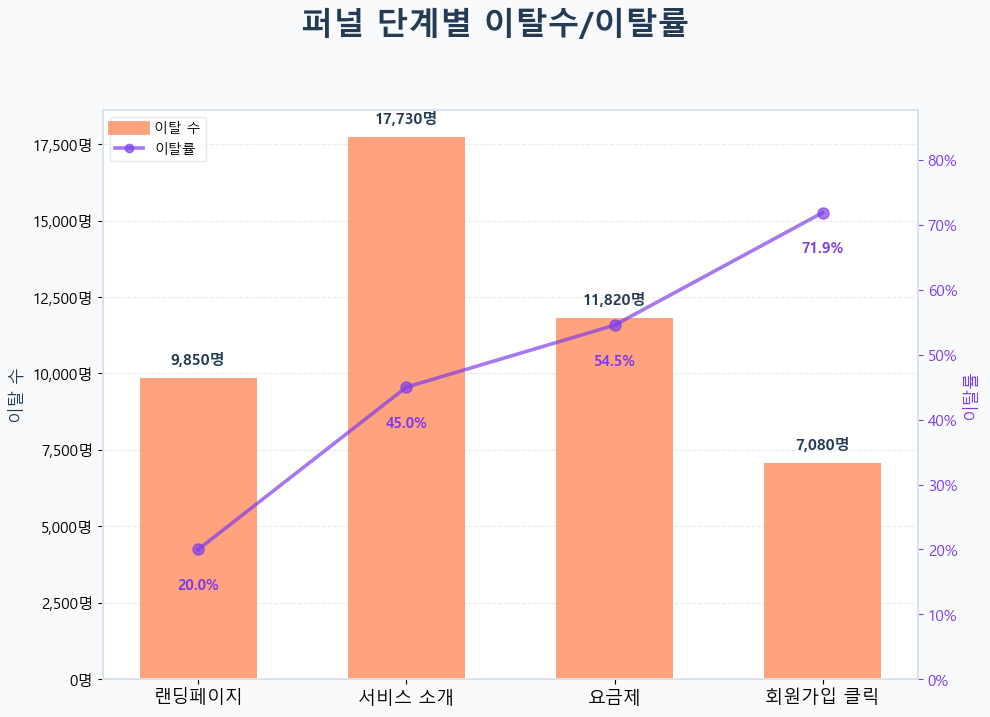

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np

# =========================================================
# 1) Raw data
# =========================================================
funnel_rows = [
    {"stage": "랜딩페이지 진입", "visitors": 49250},
    {"stage": "서비스 소개 섹션 도달", "visitors": 39400},
    {"stage": "요금제 섹션 도달", "visitors": 21670},
    {"stage": "회원가입 버튼 클릭", "visitors": 9850},
    {"stage": "가입 완료", "visitors": 2770},
]

df = pd.DataFrame(funnel_rows)

# =========================================================
# 2) Drop-off calculation
#    기준: 해당 단계 도달자 중 다음 단계로 못 넘어간 사람
# =========================================================
drop_df = df.copy()
drop_df["next_visitors"] = drop_df["visitors"].shift(-1)
drop_df["drop_count"] = drop_df["visitors"] - drop_df["next_visitors"]
drop_df["drop_rate"] = drop_df["drop_count"] / drop_df["visitors"]

drop_df = drop_df.iloc[:-1].copy()

drop_stage_map = {
    "랜딩페이지 진입": "랜딩페이지",
    "서비스 소개 섹션 도달": "서비스 소개",
    "요금제 섹션 도달": "요금제",
    "회원가입 버튼 클릭": "회원가입 클릭"
}
drop_df["drop_stage"] = drop_df["stage"].map(drop_stage_map)

# =========================================================
# 3) Font / style
# =========================================================
plt.rcParams["font.family"] = ["AppleGothic", "Malgun Gothic", "NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

bg_color = "#F8FAFC"
border_color = "#D9E2EC"
text_color = "#243B53"

bar_color = "#FF8A5B"
line_color = "#7C3AED"

# =========================================================
# 4) Vertical bar + line plot
# =========================================================
fig, ax1 = plt.subplots(figsize=(10, 7.5))
fig.patch.set_facecolor(bg_color)
ax1.set_facecolor("white")

for spine in ax1.spines.values():
    spine.set_edgecolor(border_color)
    spine.set_linewidth(1.2)

x = np.arange(len(drop_df))

bars = ax1.bar(
    x,
    drop_df["drop_count"],
    width=0.56,
    color=bar_color,
    alpha=0.78
)

ax1.set_xticks(x)
ax1.set_xticklabels(drop_df["drop_stage"], fontsize=13)
ax1.set_ylabel("이탈 수", fontsize=12, color=text_color)
ax1.tick_params(axis="y", labelsize=11)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{int(y):,}명"))
ax1.grid(axis="y", linestyle="--", alpha=0.25)
ax1.set_axisbelow(True)

for bar in bars:
    value = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        value + drop_df["drop_count"].max() * 0.018,
        f"{int(value):,}명",
        ha="center",
        va="bottom",
        fontsize=11,
        color=text_color,
        fontweight="bold"
    )

# 이탈률 line
ax2 = ax1.twinx()

for spine in ax2.spines.values():
    spine.set_edgecolor(border_color)
    spine.set_linewidth(1.2)

ax2.plot(
    x,
    drop_df["drop_rate"] * 100,
    color=line_color,
    marker="o",
    linewidth=2.6,
    markersize=8,
    alpha=0.68
)

ax2.set_ylabel("이탈률", fontsize=12, color=line_color)
ax2.tick_params(axis="y", labelsize=11, colors=line_color)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.0f}%"))
ax2.set_ylim(0, max(drop_df["drop_rate"] * 100) * 1.22)

for xi, rate in zip(x, drop_df["drop_rate"] * 100):
    ax2.text(
        xi,
        rate - max(drop_df["drop_rate"] * 100) * 0.06,
        f"{rate:.1f}%",
        ha="center",
        va="top",
        fontsize=10.5,
        color=line_color,
        fontweight="bold"
    )

fig.suptitle(
    "퍼널 단계별 이탈수/이탈률",
    fontsize=23,
    fontweight="bold",
    color=text_color,
    y=0.97
)


legend_items = [
    plt.Line2D([0], [0], color=bar_color, lw=10, alpha=0.78),
    plt.Line2D([0], [0], color=line_color, marker="o", lw=2.6, alpha=0.68)
]
ax1.legend(
    legend_items,
    ["이탈 수", "이탈률"],
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor=border_color,
    fontsize=10
)

plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.show()

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

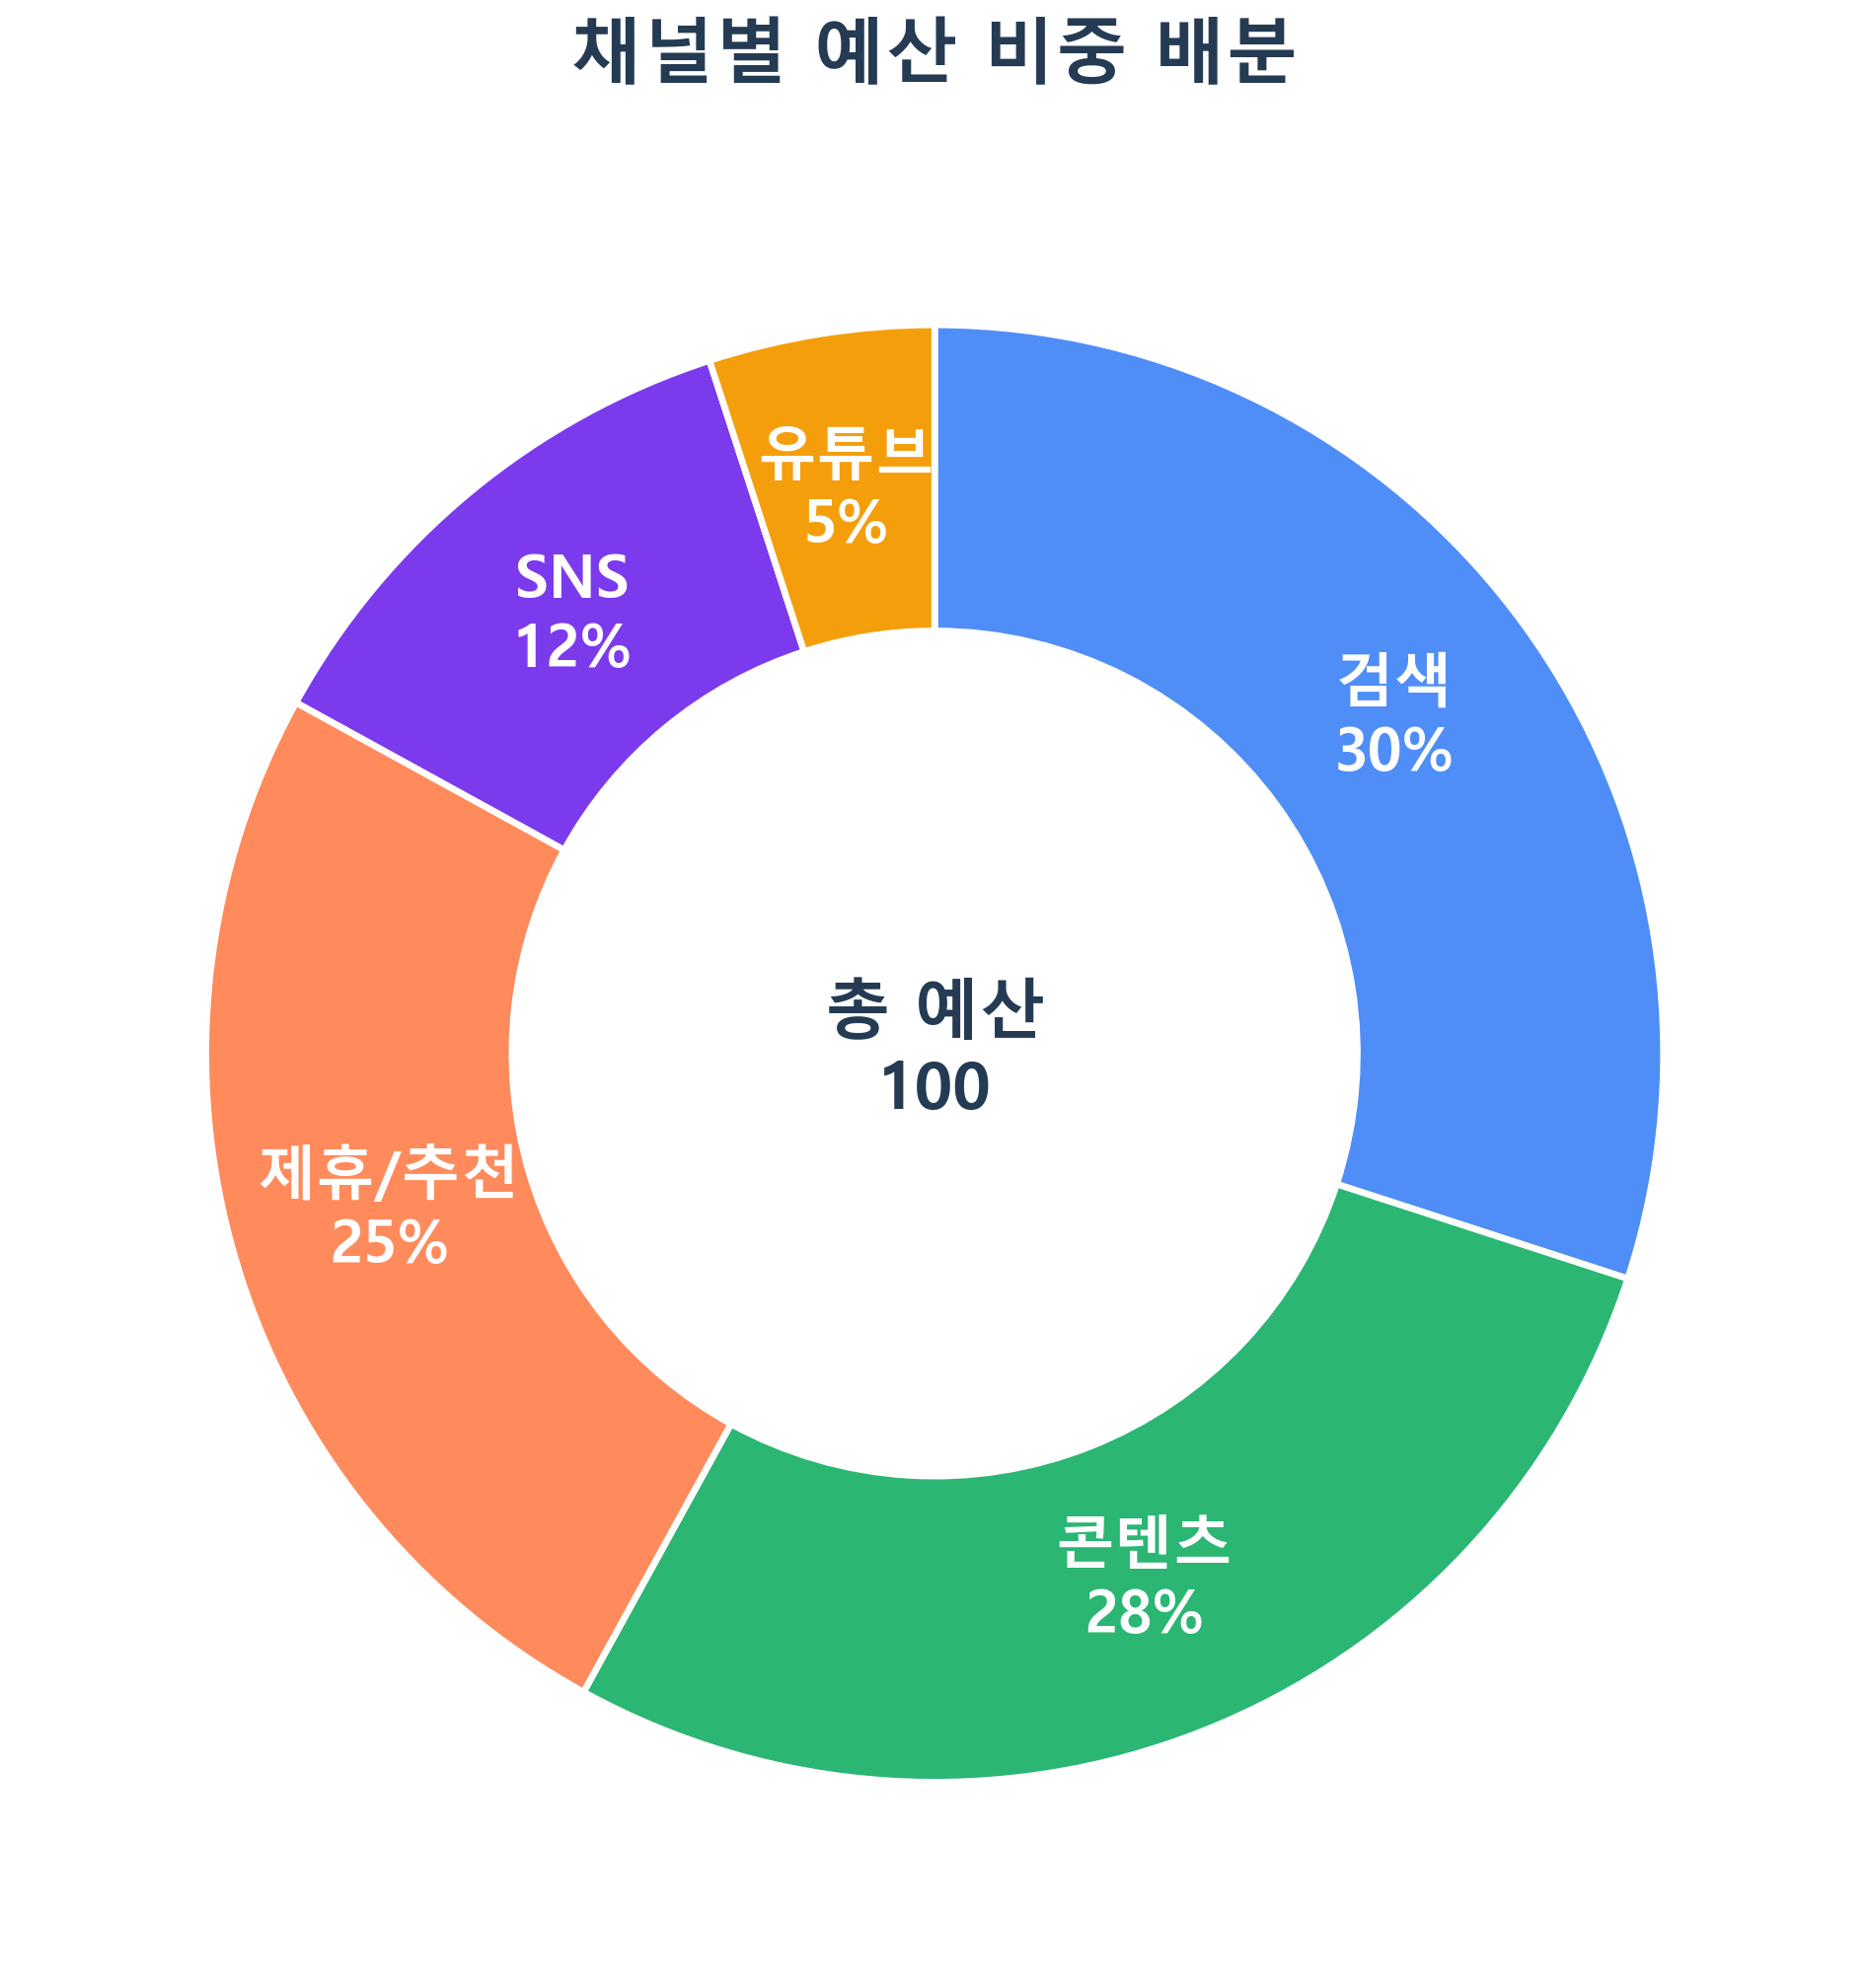

In [39]:
import matplotlib.pyplot as plt

# =========================================================
# 1) Data
# =========================================================
labels = ["검색", "콘텐츠", "제휴/추천", "SNS", "유튜브"]
sizes = [30, 28, 25, 12, 5]

# =========================================================
# 2) Style
# =========================================================
plt.rcParams["font.family"] = ["AppleGothic", "Malgun Gothic", "NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

colors = ["#4F8EF7", "#2BB673", "#FF8A5B", "#7C3AED", "#F59E0B"]
text_color = "#243B53"

# =========================================================
# 3) Label formatter
# =========================================================
def autopct_with_label(labels):
    idx = {"value": 0}
    def inner(pct):
        label = labels[idx["value"]]
        idx["value"] += 1
        return f"{label}\n{pct:.0f}%"
    return inner

# =========================================================
# 4) Donut chart
# =========================================================
fig, ax = plt.subplots(figsize=(10.5, 8.5), facecolor="none", dpi=240)
ax.set_facecolor("none")

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
    autopct=autopct_with_label(labels),
    pctdistance=0.78,
    textprops=dict(color="white", fontsize=14, fontweight="bold")
)

# 도넛 내부 라벨 크기 추가 조정
for autotext in autotexts:
    autotext.set_fontsize(18)
    autotext.set_fontweight("bold")

# 중앙 텍스트
ax.text(
    0, 0,
    "총 예산\n100",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    color=text_color
)


# 제목
ax.set_title(
    "채널별 예산 비중 배분",
    fontsize=22,
    fontweight="bold",
    color=text_color,
    pad=20
)

ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

channel = pd.DataFrame(channel_rows)
funnel = pd.DataFrame(funnel_rows)
segment = pd.DataFrame(segment_rows)
 
    #1. 마케팅 실태 및 현황 보고
    
#현황
total_visit_counts = channel['visit_counts'].sum()
total_sign_counts = channel['sign'].sum()
overall_sign_rate = (total_sign_counts/total_visit_counts).round(4)
total_cost = (channel['sign'] * channel['cac']).sum()
avg_cac = (total_cost / total_sign_counts).round(4)

#목표치 gap #전환율 = 가입수 / 방문수
target_sign_rate = 0.15 - overall_sign_rate
target_sign_counts = ((total_sign_counts * 0.15) / overall_sign_rate).round(4)
target_cost = (target_sign_counts - total_sign_counts) * avg_cac


data_summary = pd.DataFrame([{
    "현재 전환율(%)": round(overall_sign_rate * 100, 2),
    "목표 전환율(%)": round(0.15 * 100, 2),
    "전환율 gap(%p)": round(target_sign_rate * 100, 2),
    "현재 가입 수": round(total_sign_counts, 0),
    "목표 가입 수": round(target_sign_counts, 0),
    "가입수 gap": round(target_sign_counts-total_sign_counts, 0),
    "예상 추가비용": round(target_cost, 0)
}])
data_summary

#분석결과
#

,현재 전환율(%),목표 전환율(%),전환율 gap(%p),현재 가입 수,목표 가입 수,가입수 gap,예상 추가비용
0,5.62,15.0,9.38,2770,7393.0,4623.0,134918447.0


     유입 경로     노출수    클릭수   CTR    방문수  회원가입수  가입전환율  CAC(고객1명당 획득 비용)  \
0     검색광고  320000  19200  0.06  17500   1050   0.06             28000   
1   SNS 광고  500000  20000  0.04  18200    728   0.04             41000   
2   유튜브 광고  210000   6300  0.03   5900    236   0.04             48000   
3  콘텐츠 마케팅   85000   5950  0.07   5400    486   0.09             15000   
4    제휴/추천   40000   2400  0.06   2250    270   0.12             11000   

        총비용      비용비중     가입기여도    운영효율지수      초과비용  
0  29400000  0.363699  0.379061  1.042238  17850000  
1  29848000  0.369241  0.262816  0.711772  21840000  
2  11328000  0.140136  0.085199  0.607972   8732000  
3   7290000  0.090183  0.175451  1.945511   1944000  
4   2970000  0.036741  0.097473  2.652970         0  
     유입 경로           CPM          CPC    CAC  CPM 순위  CPC 순위  CAC 순위
4    제휴/추천  74250.000000  1237.500000  11000       3       2       1
3  콘텐츠 마케팅  85764.705882  1225.210084  15000       4       1       2
0     검색광고  91875.000000

C:\Users\박중현\AppData\Local\Temp\ipykernel_12376\1184206381.py:361: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  report["시각자료"]["채널구조진단"].show()
C:\Users\박중현\AppData\Local\Temp\ipykernel_12376\1184206381.py:362: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  report["시각자료"]["비용구조진단"].show()


,유입 경로,노출수,클릭수,CTR,방문수,회원가입수,가입전환율,CAC(고객1명당 획득 비용),총비용,비용비중,가입기여도,운영효율지수,초과비용
0,검색광고,320000,19200,0.06,17500,1050,0.06,28000,29400000,0.363699,0.379061,1.042238,17850000
1,SNS 광고,500000,20000,0.04,18200,728,0.04,41000,29848000,0.369241,0.262816,0.711772,21840000
2,유튜브 광고,210000,6300,0.03,5900,236,0.04,48000,11328000,0.140136,0.085199,0.607972,8732000
3,콘텐츠 마케팅,85000,5950,0.07,5400,486,0.09,15000,7290000,0.090183,0.175451,1.945511,1944000
4,제휴/추천,40000,2400,0.06,2250,270,0.12,11000,2970000,0.036741,0.097473,2.652970,0


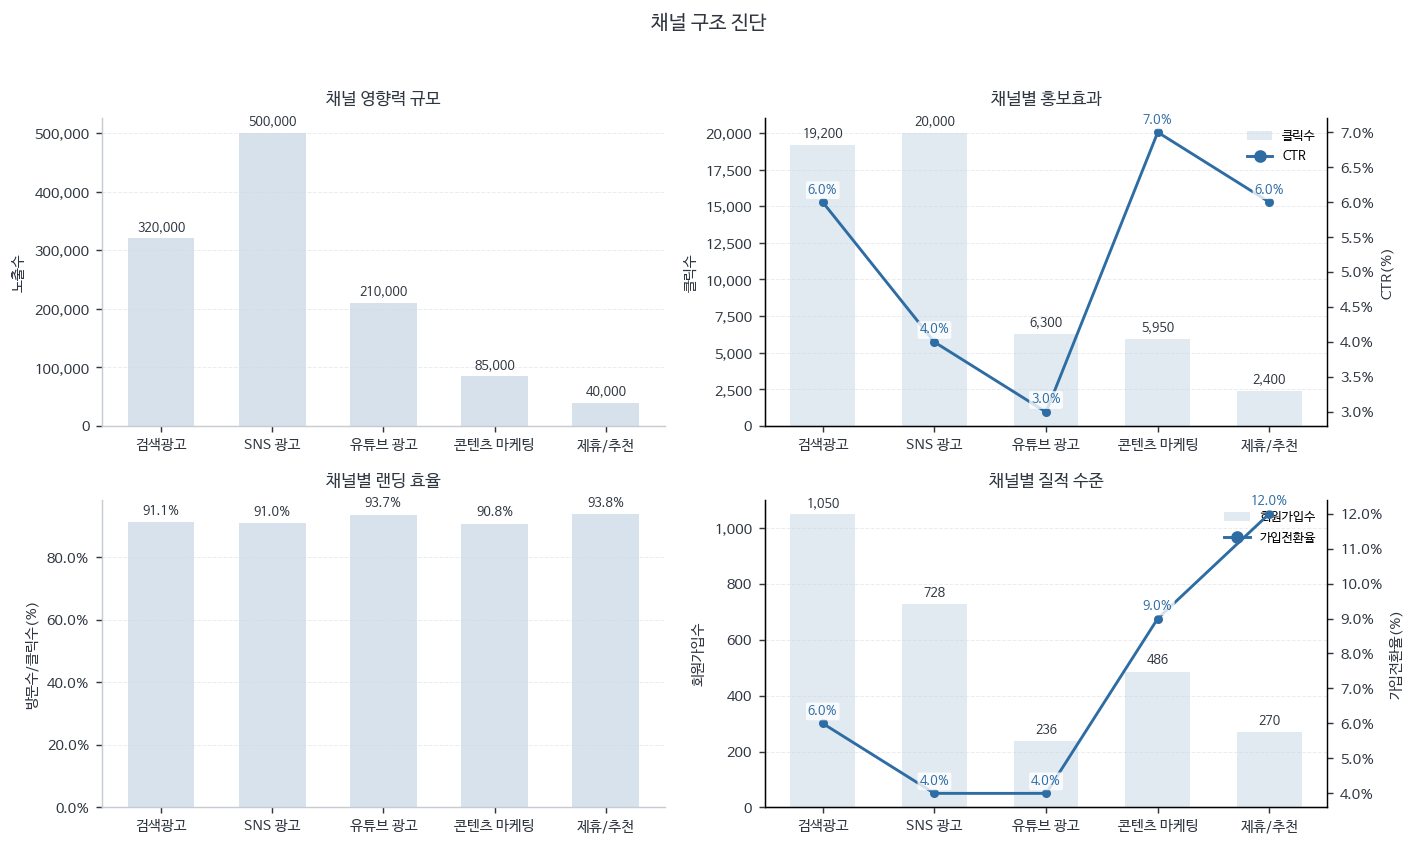

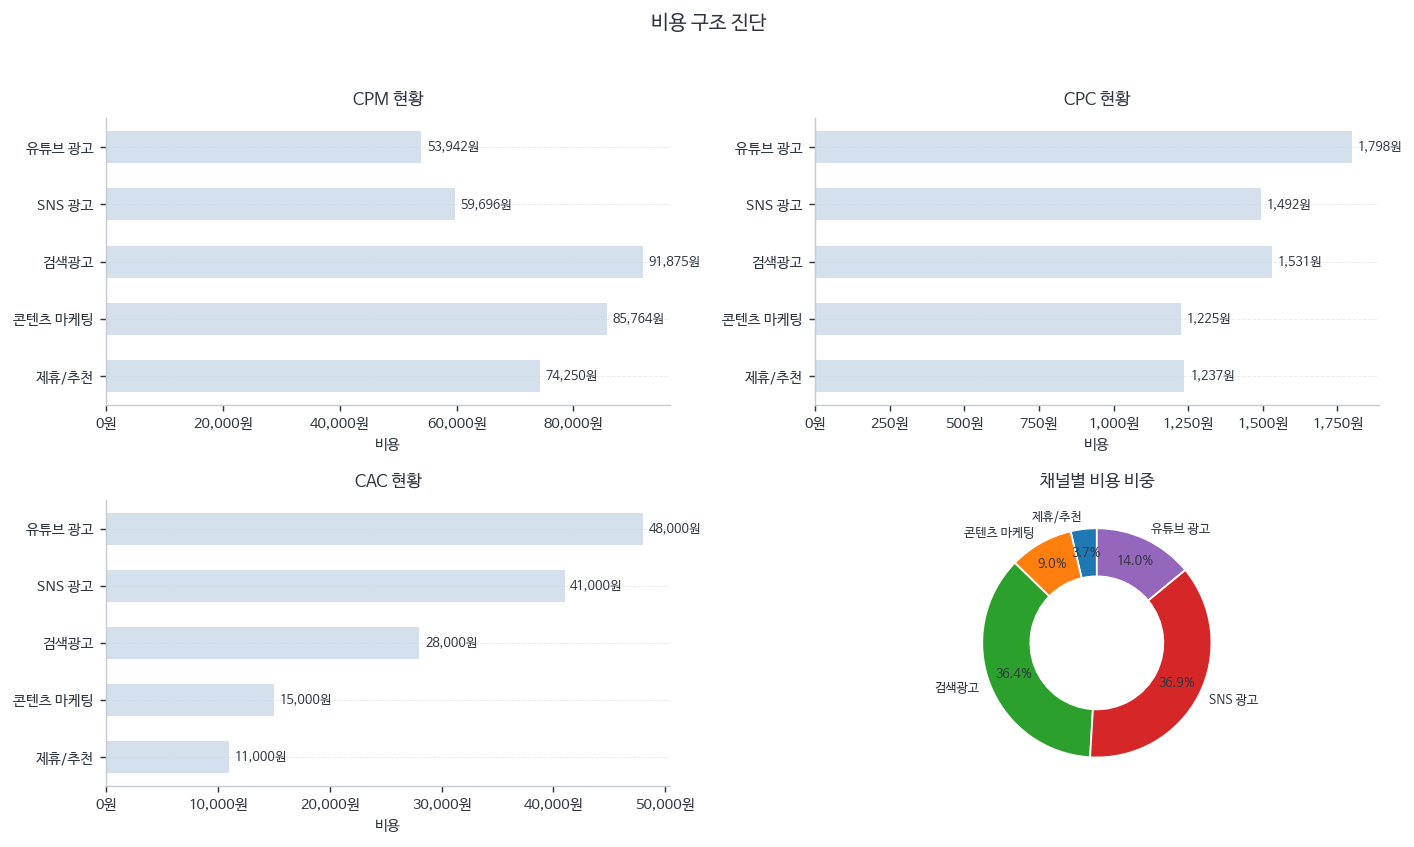

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager as fm
import matplotlib as mpl

# =========================================================
# 1. 한글 폰트 설정: 파일 경로 직접 지정
# =========================================================
FONT_PATH = r"c:\Windows\Fonts\NanumBarunGothic.ttf"
url = r'c:\Windows\Fonts\NanumBarunGothic.ttf'
fm.fontManager.addfont(url)
plt.rc('font', family=fm.FontProperties(fname=url).get_name())
def set_korean_font(font_path=FONT_PATH):
    font_prop = fm.FontProperties(fname=font_path)
    font_name = font_prop.get_name()
    mpl.rcParams["font.family"] = font_name
    mpl.rcParams["axes.unicode_minus"] = False
    return font_prop


# =========================================================
# 2. 원본 데이터
# =========================================================
channel_rows = [
    {"ch": "search",   "impression": 320000, "click_counts": 19200, "ctr": 0.06, "visit_counts": 17500, "sign": 1050, "sign_rate": 0.06, "cac": 28000},
    {"ch": "sns",      "impression": 500000, "click_counts": 20000, "ctr": 0.04, "visit_counts": 18200, "sign": 728,  "sign_rate": 0.04, "cac": 41000},
    {"ch": "youtube",  "impression": 210000, "click_counts": 6300,  "ctr": 0.03, "visit_counts": 5900,  "sign": 236,  "sign_rate": 0.04, "cac": 48000},
    {"ch": "content",  "impression": 85000,  "click_counts": 5950,  "ctr": 0.07, "visit_counts": 5400,  "sign": 486,  "sign_rate": 0.09, "cac": 15000},
    {"ch": "referral", "impression": 40000,  "click_counts": 2400,  "ctr": 0.06, "visit_counts": 2250,  "sign": 270,  "sign_rate": 0.12, "cac": 11000},
]

CHANNEL_NAME_MAP = {
    "search": "검색광고",
    "sns": "SNS 광고",
    "youtube": "유튜브 광고",
    "content": "콘텐츠 마케팅",
    "referral": "제휴/추천"
}


# =========================================================
# 3. 포맷 함수
# =========================================================
def won_formatter(x, pos):
    return f"{int(x):,}원"

def int_formatter(x, pos):
    return f"{int(x):,}"

def pct_formatter(x, pos):
    return f"{x:.1f}%"

def fmt_pct(x, digits=1):
    return f"{x * 100:.{digits}f}%"


# =========================================================
# 4. 전처리
# =========================================================
def prepare_channel_df(channel_rows):
    df = pd.DataFrame(channel_rows).copy()
    df["유입 경로"] = df["ch"].map(CHANNEL_NAME_MAP)

    df["총비용"] = df["cac"] * df["sign"]
    df["방문수/클릭수"] = np.where(df["click_counts"] > 0, df["visit_counts"] / df["click_counts"], np.nan)
    df["가입기여도"] = df["sign"] / df["sign"].sum()
    df["비용비중"] = df["총비용"] / df["총비용"].sum()
    df["운영효율지수"] = df["가입기여도"] / df["비용비중"]

    df["cpm"] = np.where(df["impression"] > 0, df["총비용"] / df["impression"] * 1000, np.nan)
    df["cpc"] = np.where(df["click_counts"] > 0, df["총비용"] / df["click_counts"], np.nan)

    benchmark_cac = df["cac"].min()
    df["기준CAC"] = benchmark_cac
    df["초과비용"] = np.where(df["cac"] > benchmark_cac, (df["cac"] - benchmark_cac) * df["sign"], 0)

    df["CPM 순위"] = df["cpm"].rank(method="min", ascending=True).astype(int)
    df["CPC 순위"] = df["cpc"].rank(method="min", ascending=True).astype(int)
    df["CAC 순위"] = df["cac"].rank(method="min", ascending=True).astype(int)

    return df


# =========================================================
# 5. 요약표
# =========================================================
def make_channel_summary_table(channel_df):
    summary = channel_df[[
        "유입 경로", "impression", "click_counts", "ctr",
        "visit_counts", "sign", "sign_rate", "cac",
        "총비용", "비용비중", "가입기여도", "운영효율지수", "초과비용"
    ]].copy()

    summary.columns = [
        "유입 경로", "노출수", "클릭수", "CTR",
        "방문수", "회원가입수", "가입전환율", "CAC(고객1명당 획득 비용)",
        "총비용", "비용비중", "가입기여도", "운영효율지수", "초과비용"
    ]
    return summary


def make_cost_rank_table(channel_df):
    rank_df = channel_df[["유입 경로", "cpm", "cpc", "cac", "CPM 순위", "CPC 순위", "CAC 순위"]].copy()
    rank_df.columns = ["유입 경로", "CPM", "CPC", "CAC", "CPM 순위", "CPC 순위", "CAC 순위"]
    return rank_df.sort_values("CAC 순위")


def make_excess_cost_table(channel_df):
    tbl = channel_df[["유입 경로", "sign", "cac", "기준CAC", "초과비용"]].copy()
    tbl.columns = ["유입 경로", "회원가입수", "CAC", "기준CAC", "초과비용"]
    return tbl.sort_values("초과비용", ascending=False)


def make_efficiency_table(channel_df):
    tbl = channel_df[["유입 경로", "비용비중", "가입기여도", "운영효율지수"]].copy()
    tbl.columns = ["유입 경로", "비용비중", "가입기여도", "운영효율지수"]
    return tbl.sort_values("운영효율지수", ascending=False)


# =========================================================
# 6. 스타일
# =========================================================
BAR_COLOR = "#C9D8E6"     # 연한 블루그레이
LINE_COLOR = "#2E6DA4"    # 진한 블루
GRID_COLOR = "#D9DDE3"
TEXT_COLOR = "#2F3640"
ACCENT_COLOR = "#D07A2D"  # 작은 포인트 색
BG_COLOR = "#FFFFFF"

def apply_report_style(ax, title):
    ax.set_title(title, fontsize=9.5, fontweight="semibold", pad=8, color=TEXT_COLOR)
    ax.grid(axis="y", linestyle="--", linewidth=0.55, alpha=0.55, color=GRID_COLOR)
    ax.set_axisbelow(True)
    ax.set_facecolor(BG_COLOR)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#C7CCD4")
    ax.spines["bottom"].set_color("#C7CCD4")
    ax.tick_params(axis="both", labelsize=8, colors=TEXT_COLOR)


def annotate_bars(ax, bars, fmt_func, fontsize=7, offset_ratio=0.012):
    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * offset_ratio
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + offset,
            fmt_func(h),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            color=TEXT_COLOR
        )


def annotate_line_points(ax, x, y, fmt_func, fontsize=7):
    for xi, yi in zip(x, y):
        ax.annotate(
            fmt_func(yi),
            (xi, yi),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            fontsize=fontsize,
            color=LINE_COLOR,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8)
        )


def annotate_barh(ax, bars, fmt_func, fontsize=7):
    x_min, x_max = ax.get_xlim()
    offset = (x_max - x_min) * 0.01
    for b in bars:
        w = b.get_width()
        ax.text(
            w + offset,
            b.get_y() + b.get_height() / 2,
            fmt_func(w),
            va="center",
            fontsize=fontsize,
            color=TEXT_COLOR
        )


# =========================================================
# 7. 채널 구조 그래프
# =========================================================
def plot_channel_structure(channel_df):
    df = channel_df.copy()
    labels = df["유입 경로"].tolist()
    x = np.arange(len(df))

    fig, axes = plt.subplots(2, 2, figsize=(11, 6.6), dpi=130)
    fig.patch.set_facecolor("white")
    fig.suptitle("채널 구조 진단", fontsize=11, fontweight="bold", y=0.98, color=TEXT_COLOR)

    # 1) 채널 영향력 -> 노출수
    ax = axes[0, 0]
    bars = ax.bar(labels, df["impression"], color=BAR_COLOR, alpha=0.75, width=0.6)
    apply_report_style(ax, "채널 영향력 규모")
    ax.set_ylabel("노출수", fontsize=8, color=TEXT_COLOR)
    ax.yaxis.set_major_formatter(FuncFormatter(int_formatter))
    annotate_bars(ax, bars, lambda v: f"{int(v):,}", fontsize=7)

    # 2) 채널 홍보효과 -> 클릭수 + CTR
    ax = axes[0, 1]
    bars = ax.bar(labels, df["click_counts"], color=BAR_COLOR, alpha=0.55, width=0.58, zorder=2)
    apply_report_style(ax, "채널별 홍보효과")
    ax.set_ylabel("클릭수", fontsize=8, color=TEXT_COLOR)
    ax.yaxis.set_major_formatter(FuncFormatter(int_formatter))
    annotate_bars(ax, bars, lambda v: f"{int(v):,}", fontsize=7)

    ax2 = ax.twinx()
    ax2.plot(x, df["ctr"] * 100, color=LINE_COLOR, marker="o", linewidth=1.6, markersize=4, zorder=3)
    ax2.set_ylabel("CTR(%)", fontsize=8, color=TEXT_COLOR)
    ax2.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
    ax2.tick_params(axis="y", labelsize=8, colors=TEXT_COLOR)
    ax2.spines["top"].set_visible(False)
    annotate_line_points(ax2, x, df["ctr"] * 100, lambda v: f"{v:.1f}%", fontsize=7)

    ax.legend(
        handles=[
            Patch(facecolor=BAR_COLOR, edgecolor="none", alpha=0.55, label="클릭수"),
            Line2D([0], [0], color=LINE_COLOR, marker='o', linewidth=1.6, label="CTR")
        ],
        loc="upper right",
        fontsize=7,
        frameon=False
    )

    # 3) 채널 랜딩 문제 -> 방문수/클릭수
    ax = axes[1, 0]
    bars = ax.bar(labels, df["방문수/클릭수"] * 100, color=BAR_COLOR, alpha=0.72, width=0.6)
    apply_report_style(ax, "채널별 랜딩 효율")
    ax.set_ylabel("방문수/클릭수(%)", fontsize=8, color=TEXT_COLOR)
    ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
    annotate_bars(ax, bars, lambda v: f"{v:.1f}%", fontsize=7)

    # 4) 채널 질적 수준 -> 회원가입수 + 가입전환율
    ax = axes[1, 1]
    bars = ax.bar(labels, df["sign"], color=BAR_COLOR, alpha=0.55, width=0.58, zorder=2)
    apply_report_style(ax, "채널별 질적 수준")
    ax.set_ylabel("회원가입수", fontsize=8, color=TEXT_COLOR)
    ax.yaxis.set_major_formatter(FuncFormatter(int_formatter))
    annotate_bars(ax, bars, lambda v: f"{int(v):,}", fontsize=7)

    ax2 = ax.twinx()
    ax2.plot(x, df["sign_rate"] * 100, color=LINE_COLOR, marker="o", linewidth=1.6, markersize=4, zorder=3)
    ax2.set_ylabel("가입전환율(%)", fontsize=8, color=TEXT_COLOR)
    ax2.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
    ax2.tick_params(axis="y", labelsize=8, colors=TEXT_COLOR)
    ax2.spines["top"].set_visible(False)
    annotate_line_points(ax2, x, df["sign_rate"] * 100, lambda v: f"{v:.1f}%", fontsize=7)

    ax.legend(
        handles=[
            Patch(facecolor=BAR_COLOR, edgecolor="none", alpha=0.55, label="회원가입수"),
            Line2D([0], [0], color=LINE_COLOR, marker='o', linewidth=1.6, label="가입전환율")
        ],
        loc="upper right",
        fontsize=7,
        frameon=False
    )

    for ax in axes.flat:
        ax.tick_params(axis="x", rotation=0, labelsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig


# =========================================================
# 8. 비용 구조 그래프
# =========================================================
def plot_channel_costs(channel_df):
    df = channel_df.copy().sort_values("cac")
    labels = df["유입 경로"].tolist()

    fig, axes = plt.subplots(2, 2, figsize=(11, 6.6), dpi=130)
    fig.patch.set_facecolor("white")
    fig.suptitle("비용 구조 진단", fontsize=11, fontweight="bold", y=0.98, color=TEXT_COLOR)

    # 1) CPM
    ax = axes[0, 0]
    bars = ax.barh(labels, df["cpm"], color=BAR_COLOR, alpha=0.78, height=0.56)
    apply_report_style(ax, "CPM 현황")
    ax.set_xlabel("비용", fontsize=8, color=TEXT_COLOR)
    ax.xaxis.set_major_formatter(FuncFormatter(won_formatter))
    annotate_barh(ax, bars, lambda v: f"{int(v):,}원", fontsize=7)

    # 2) CPC
    ax = axes[0, 1]
    bars = ax.barh(labels, df["cpc"], color=BAR_COLOR, alpha=0.78, height=0.56)
    apply_report_style(ax, "CPC 현황")
    ax.set_xlabel("비용", fontsize=8, color=TEXT_COLOR)
    ax.xaxis.set_major_formatter(FuncFormatter(won_formatter))
    annotate_barh(ax, bars, lambda v: f"{int(v):,}원", fontsize=7)

    # 3) CAC
    ax = axes[1, 0]
    bars = ax.barh(labels, df["cac"], color=BAR_COLOR, alpha=0.78, height=0.56)
    apply_report_style(ax, "CAC 현황")
    ax.set_xlabel("비용", fontsize=8, color=TEXT_COLOR)
    ax.xaxis.set_major_formatter(FuncFormatter(won_formatter))
    annotate_barh(ax, bars, lambda v: f"{int(v):,}원", fontsize=7)

    # 4) 비용 비중 도넛
    ax = axes[1, 1]
    wedges, texts, autotexts = ax.pie(
        df["총비용"],
        labels=df["유입 경로"],
        autopct=lambda p: f"{p:.1f}%",
        startangle=90,
        pctdistance=0.78,
        textprops={"fontsize": 7, "color": TEXT_COLOR},
        wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 1}
    )
    ax.set_title("채널별 비용 비중", fontsize=9.5, fontweight="semibold", pad=8, color=TEXT_COLOR)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig


# =========================================================
# 9. 비용 구조 표
# =========================================================
def build_channel_report(channel_rows, font_path=FONT_PATH):
    set_korean_font(font_path)

    channel_df = prepare_channel_df(channel_rows)

    report = {
        "전체요약표": make_channel_summary_table(channel_df),
        "비용순위표": make_cost_rank_table(channel_df),
        "초과비용표": make_excess_cost_table(channel_df),
        "운영효율표": make_efficiency_table(channel_df),
        "시각자료": {
            "채널구조진단": plot_channel_structure(channel_df),
            "비용구조진단": plot_channel_costs(channel_df),
        }
    }
    return report


# =========================================================
# 10. 사용 예시
# =========================================================
report = build_channel_report(channel_rows)

print(report["전체요약표"])
print(report["비용순위표"])
print(report["초과비용표"])
print(report["운영효율표"])

report["시각자료"]["채널구조진단"].show()
report["시각자료"]["비용구조진단"].show()

report['전체요약표']

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager as fm
import matplotlib as mpl

# =========================================================
# 1. 한글 폰트 설정
# =========================================================


# =========================================================
# 2. 포맷/스타일
# =========================================================
BAR_COLOR = "#C9D8E6"
LINE_COLOR = "#2E6DA4"
GRID_COLOR = "#D9DDE3"
TEXT_COLOR = "#2F3640"
ACCENT_COLOR = "#D07A2D"
TARGET_COLOR = "#B65C5C"
BG_COLOR = "#FFFFFF"

FUNNEL_NAME_MAP = {
    "landing": "랜딩 진입",
    "introduction": "소개 섹션",
    "price_section": "가격 섹션",
    "signup_click": "회원가입 클릭",
    "signup_done": "회원가입 완료"
}

SEGMENT_NAME_MAP = {
    "student": "학생",
    "worker": "직장인",
    "freelancer": "프리랜서",
    "team": "팀/조직"
}

def won_formatter(x, pos):
    return f"{int(x):,}원"

def int_formatter(x, pos):
    return f"{int(x):,}"

def pct_formatter(x, pos):
    return f"{x:.1f}%"

def apply_report_style(ax, title):
    ax.set_title(title, fontsize=9.5, fontweight="semibold", pad=8, color=TEXT_COLOR)
    ax.grid(axis="y", linestyle="--", linewidth=0.55, alpha=0.55, color=GRID_COLOR)
    ax.set_axisbelow(True)
    ax.set_facecolor(BG_COLOR)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#C7CCD4")
    ax.spines["bottom"].set_color("#C7CCD4")
    ax.tick_params(axis="both", labelsize=8, colors=TEXT_COLOR)

def annotate_bars(ax, bars, fmt_func, fontsize=7, offset_ratio=0.012):
    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * offset_ratio
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + offset,
            fmt_func(h),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            color=TEXT_COLOR
        )

def annotate_line_points(ax, x, y, fmt_func, fontsize=7):
    for xi, yi in zip(x, y):
        ax.annotate(
            fmt_func(yi),
            (xi, yi),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            fontsize=fontsize,
            color=LINE_COLOR,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8)
        )


# =========================================================
# 3. 전처리
# =========================================================
def prepare_segment_df(segment_rows):
    if segment_rows is None:
        return None
    df = pd.DataFrame(segment_rows).copy()
    if "segment" in df.columns:
        df["세그먼트"] = df["segment"].map(SEGMENT_NAME_MAP).fillna(df["segment"])
    return df

def prepare_funnel_df(funnel_rows):
    df = pd.DataFrame(funnel_rows).copy()
    if "step" in df.columns:
        df["단계"] = df["step"].map(FUNNEL_NAME_MAP).fillna(df["step"])

    df["이탈수"] = df["count"].shift(0) - df["count"].shift(-1)
    df["이탈수"] = df["이탈수"].fillna(0)

    if "drop_rate" not in df.columns or df["drop_rate"].isna().all():
        df["drop_rate"] = np.where(
            df["count"].shift(0) > 0,
            (df["count"].shift(0) - df["count"].shift(-1)) / df["count"].shift(0),
            np.nan
        )

    df["drop_rate_pct"] = df["drop_rate"] * 100
    valid_drop = df["drop_rate"].dropna()
    avg_drop = valid_drop.mean() if len(valid_drop) > 0 else np.nan
    df["평균이탈률"] = avg_drop
    df["평균대비차이(%p)"] = df["drop_rate_pct"] - (avg_drop * 100 if pd.notna(avg_drop) else np.nan)

    # 이상구간 플래그
    if pd.notna(avg_drop):
        df["이상구간여부"] = np.where(
            (df["drop_rate"] >= avg_drop + 0.10) | (df["drop_rate"] == valid_drop.max()),
            "주의",
            ""
        )
    else:
        df["이상구간여부"] = ""

    return df


# =========================================================
# 4. 표 생성
# =========================================================
def make_landing_conversion_comparison_table(total_visit_counts, total_sign_counts, target_sign_rate=None, segment_rows=None):
    global_cvr = total_sign_counts / total_visit_counts if total_visit_counts > 0 else np.nan

    rows = [{
        "비교항목": "전역 가입전환율",
        "값": global_cvr
    }]

    if target_sign_rate is not None:
        rows.append({
            "비교항목": "목표 가입전환율",
            "값": target_sign_rate
        })

    if segment_rows is not None:
        segment_df = prepare_segment_df(segment_rows)
        segment_avg = segment_df["sign_rate"].mean()
        rows.append({
            "비교항목": "세그먼트 평균 가입전환율",
            "값": segment_avg
        })

    return pd.DataFrame(rows)


def make_funnel_stage_summary_table(funnel_df):
    tbl = funnel_df[["단계", "count", "이탈수", "drop_rate", "평균대비차이(%p)", "이상구간여부"]].copy()
    tbl.columns = ["단계", "유입수", "이탈수", "이탈률", "평균대비차이(%p)", "이상구간여부"]
    return tbl


# =========================================================
# 5. 그래프
# =========================================================
def plot_landing_overview(total_visit_counts, total_sign_counts, target_sign_rate=None, segment_rows=None):
    global_cvr = total_sign_counts / total_visit_counts if total_visit_counts > 0 else np.nan

    labels = ["전역 가입전환율"]
    values = [global_cvr * 100]

    if target_sign_rate is not None:
        labels.append("목표 가입전환율")
        values.append(target_sign_rate * 100)

    if segment_rows is not None:
        segment_df = prepare_segment_df(segment_rows)
        segment_avg = segment_df["sign_rate"].mean()
        labels.append("세그먼트 평균")
        values.append(segment_avg * 100)

    fig, ax = plt.subplots(figsize=(6.2, 3.8), dpi=130)
    fig.patch.set_facecolor("white")

    colors = [BAR_COLOR]
    if target_sign_rate is not None:
        colors.append(TARGET_COLOR)
    if segment_rows is not None:
        colors.append(LINE_COLOR)

    bars = ax.bar(labels, values, color=colors, alpha=0.78, width=0.58)
    apply_report_style(ax, "랜딩페이지 전반적 전환율 비교")
    ax.set_ylabel("가입전환율(%)", fontsize=8, color=TEXT_COLOR)
    ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
    annotate_bars(ax, bars, lambda v: f"{v:.1f}%", fontsize=7)
    ax.tick_params(axis="x", rotation=0, labelsize=8)

    plt.tight_layout()
    return fig


def plot_funnel_diagnostics(funnel_df):
    df = funnel_df.copy()
    x = np.arange(len(df))

    fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=130)
    fig.patch.set_facecolor("white")

    bars = ax.bar(df["단계"], df["이탈수"], color=BAR_COLOR, alpha=0.58, width=0.58, zorder=2)
    apply_report_style(ax, "퍼널 단계별 이탈 현황")
    ax.set_ylabel("이탈수", fontsize=8, color=TEXT_COLOR)
    ax.yaxis.set_major_formatter(FuncFormatter(int_formatter))
    annotate_bars(ax, bars, lambda v: f"{int(v):,}", fontsize=7)

    ax2 = ax.twinx()
    ax2.plot(x, df["drop_rate_pct"], color=LINE_COLOR, marker="o", linewidth=1.6, markersize=4, zorder=3)
    ax2.set_ylabel("이탈률(%)", fontsize=8, color=TEXT_COLOR)
    ax2.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
    ax2.tick_params(axis="y", labelsize=8, colors=TEXT_COLOR)
    ax2.spines["top"].set_visible(False)
    annotate_line_points(ax2, x, df["drop_rate_pct"], lambda v: f"{v:.1f}%", fontsize=7)

    avg_drop = df["drop_rate_pct"].dropna().mean()
    if pd.notna(avg_drop):
        ax2.axhline(avg_drop, color=ACCENT_COLOR, linestyle="--", linewidth=1.2, alpha=0.9)

    ax.legend(
        handles=[
            Patch(facecolor=BAR_COLOR, edgecolor="none", alpha=0.58, label="이탈수"),
            Line2D([0], [0], color=LINE_COLOR, marker='o', linewidth=1.6, label="이탈률"),
            Line2D([0], [0], color=ACCENT_COLOR, linestyle='--', linewidth=1.2, label="평균 이탈률")
        ],
        loc="upper right",
        fontsize=7,
        frameon=False
    )

    ax.tick_params(axis="x", rotation=0, labelsize=8)
    plt.tight_layout()
    return fig


# =========================================================
# 6. 최종 리포트 함수
# =========================================================
def build_landing_report(
    funnel_rows,
    total_visit_counts,
    total_sign_counts,
    target_sign_rate=None,
    segment_rows=None,
    font_path=FONT_PATH
):
    set_korean_font(font_path)

    funnel_df = prepare_funnel_df(funnel_rows)

    report = {
        "전환율비교표": make_landing_conversion_comparison_table(
            total_visit_counts=total_visit_counts,
            total_sign_counts=total_sign_counts,
            target_sign_rate=target_sign_rate,
            segment_rows=segment_rows
        ),
        "퍼널단계요약표": make_funnel_stage_summary_table(funnel_df),
        "시각자료": {
            "전반적전환율비교": plot_landing_overview(
                total_visit_counts=total_visit_counts,
                total_sign_counts=total_sign_counts,
                target_sign_rate=target_sign_rate,
                segment_rows=segment_rows
            ),
            "퍼널이탈진단": plot_funnel_diagnostics(funnel_df)
        }
    }
    return report

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager as fm
import matplotlib as mpl



# =========================================================
# 2. 스타일
# =========================================================
BAR_COLOR = "#C9D8E6"
LINE_COLOR = "#2E6DA4"
GRID_COLOR = "#D9DDE3"
TEXT_COLOR = "#2F3640"
ACCENT_COLOR = "#D07A2D"
BG_COLOR = "#FFFFFF"

SEGMENT_NAME_MAP = {
    "student": "학생",
    "worker": "직장인",
    "freelancer": "프리랜서",
    "team": "팀/조직"
}

def int_formatter(x, pos):
    return f"{int(x):,}"

def pct_formatter(x, pos):
    return f"{x:.1f}%"

def apply_report_style(ax, title):
    ax.set_title(title, fontsize=9.5, fontweight="semibold", pad=8, color=TEXT_COLOR)
    ax.grid(axis="y", linestyle="--", linewidth=0.55, alpha=0.55, color=GRID_COLOR)
    ax.set_axisbelow(True)
    ax.set_facecolor(BG_COLOR)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#C7CCD4")
    ax.spines["bottom"].set_color("#C7CCD4")
    ax.tick_params(axis="both", labelsize=8, colors=TEXT_COLOR)

def annotate_bars(ax, bars, fmt_func, fontsize=7, offset_ratio=0.012):
    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * offset_ratio if y_max > y_min else 0
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            h + offset,
            fmt_func(h),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            color=TEXT_COLOR
        )

def annotate_line_points(ax, x, y, fmt_func, fontsize=7):
    for xi, yi in zip(x, y):
        ax.annotate(
            fmt_func(yi),
            (xi, yi),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            fontsize=fontsize,
            color=LINE_COLOR,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8)
        )

def annotate_scatter(ax, x, y, labels, fontsize=7):
    for xi, yi, label in zip(x, y, labels):
        ax.annotate(
            label,
            (xi, yi),
            
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=fontsize,
            color=TEXT_COLOR,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75)
        )


# =========================================================
# 3. 전처리
# =========================================================
def prepare_segment_df(segment_rows, total_visit_counts=None):
    df = pd.DataFrame(segment_rows).copy()

    if "segment" in df.columns:
        df["세그먼트"] = df["segment"].map(SEGMENT_NAME_MAP).fillna(df["segment"])
    else:
        df["세그먼트"] = df["세그먼트"]

    df["유입비중"] = df["visit_share"]
    df["전환율"] = df["sign_rate"]

    if total_visit_counts is not None:
        df["추정유입수"] = (df["유입비중"] * total_visit_counts).round().astype(int)
        df["추정전환수"] = (df["추정유입수"] * df["전환율"]).round().astype(int)
    else:
        df["추정유입수"] = np.nan
        df["추정전환수"] = np.nan

    total_sign_est = df["추정전환수"].sum(skipna=True)
    if pd.notna(total_sign_est) and total_sign_est > 0:
        df["전환비중"] = df["추정전환수"] / total_sign_est
    else:
        df["전환비중"] = np.nan

    df["유입-전환 갭(%p)"] = (df["전환율"] - df["유입비중"]) * 100
    df["유입×전환 인덱스"] = df["유입비중"] * df["전환율"]

    avg_visit_share = df["유입비중"].mean()
    avg_sign_rate = df["전환율"].mean()

    def classify(row):
        high_visit = row["유입비중"] >= avg_visit_share
        high_conv = row["전환율"] >= avg_sign_rate
        if high_visit and high_conv:
            return "핵심 타깃"
        elif high_visit and not high_conv:
            return "규모 크나 효율 약함"
        elif (not high_visit) and high_conv:
            return "잠재력 높은 타깃"
        else:
            return "우선순위 낮음"

    df["진단"] = df.apply(classify, axis=1)

    return df


# =========================================================
# 4. 요약표
# =========================================================
def make_segment_summary_table(segment_df):
    summary = segment_df[[
        "세그먼트", "유입비중", "전환율", "추정유입수",
        "추정전환수", "전환비중", "유입-전환 갭(%p)",
        "유입×전환 인덱스", "진단"
    ]].copy()

    summary.columns = [
        "세그먼트", "유입비중", "전환율", "추정유입수",
        "추정전환수", "전환비중", "유입-전환 갭(%p)",
        "유입×전환 인덱스", "진단"
    ]
    return summary


def make_segment_index_rank_table(segment_df):
    tbl = segment_df[["세그먼트", "유입비중", "전환율", "유입×전환 인덱스", "진단"]].copy()
    return tbl.sort_values("유입×전환 인덱스", ascending=False).set_index("세그먼트")


# =========================================================
# 5. 시각화
# =========================================================
def plot_segment_overview(segment_df):
    df = segment_df.copy()
    labels = df["세그먼트"].tolist()
    x = np.arange(len(df))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.1), dpi=130)
    fig.patch.set_facecolor("white")
    fig.suptitle("세그먼트 현황 파악", fontsize=11, fontweight="bold", y=0.98, color=TEXT_COLOR)

    # 1) 유입비중 + 전환율
    ax = axes[0]
    bars = ax.bar(labels, df["유입비중"] * 100, color=BAR_COLOR, alpha=0.58, width=0.58, zorder=2)
    apply_report_style(ax, "유입비중과 전환율 비교")
    ax.set_ylabel("유입비중(%)", fontsize=8, color=TEXT_COLOR)
    ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
    annotate_bars(ax, bars, lambda v: f"{v:.1f}%", fontsize=7)

    ax2 = ax.twinx()
    ax2.plot(x, df["전환율"] * 100, color=LINE_COLOR, marker="o", linewidth=1.6, markersize=4, zorder=3)
    ax2.set_ylabel("전환율(%)", fontsize=8, color=TEXT_COLOR)
    ax2.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
    ax2.tick_params(axis="y", labelsize=8, colors=TEXT_COLOR)
    ax2.spines["top"].set_visible(False)
    annotate_line_points(ax2, x, df["전환율"] * 100, lambda v: f"{v:.1f}%", fontsize=7)

    ax.legend(
        handles=[
            Patch(facecolor=BAR_COLOR, edgecolor="none", alpha=0.58, label="유입비중"),
            Line2D([0], [0], color=LINE_COLOR, marker='o', linewidth=1.6, label="전환율")
        ],
        loc="upper right",
        fontsize=7,
        frameon=False
    )
    ax.tick_params(axis="x", rotation=0, labelsize=8)

    # 2) 전환수 + 전환율
    ax = axes[1]
    bars = ax.bar(labels, df["추정전환수"], color=BAR_COLOR, alpha=0.58, width=0.58, zorder=2)
    apply_report_style(ax, "전환수와 전환율 비교")
    ax.set_ylabel("추정전환수", fontsize=8, color=TEXT_COLOR)
    ax.yaxis.set_major_formatter(FuncFormatter(int_formatter))
    annotate_bars(ax, bars, lambda v: f"{int(v):,}", fontsize=7)

    ax2 = ax.twinx()
    ax2.plot(x, df["전환율"] * 100, color=LINE_COLOR, marker="o", linewidth=1.6, markersize=4, zorder=3)
    ax2.set_ylabel("전환율(%)", fontsize=8, color=TEXT_COLOR)
    ax2.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
    ax2.tick_params(axis="y", labelsize=8, colors=TEXT_COLOR)
    ax2.spines["top"].set_visible(False)
    annotate_line_points(ax2, x, df["전환율"] * 100, lambda v: f"{v:.1f}%", fontsize=7)

    ax.legend(
        handles=[
            Patch(facecolor=BAR_COLOR, edgecolor="none", alpha=0.58, label="추정전환수"),
            Line2D([0], [0], color=LINE_COLOR, marker='o', linewidth=1.6, label="전환율")
        ],
        loc="upper right",
        fontsize=7,
        frameon=False
    )
    ax.tick_params(axis="x", rotation=0, labelsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig.subplots_adjust(wspace=0.28)
    return fig


def plot_segment_problem_diagnostics(segment_df):
    df = segment_df.copy()

    fig, ax = plt.subplots(figsize=(6.2, 4.2), dpi=130)
    fig.patch.set_facecolor("white")

    color_map = {
        "핵심 타깃": LINE_COLOR,
        "규모 크나 효율 약함": "#B65C5C",
        "잠재력 높은 타깃": ACCENT_COLOR,
        "우선순위 낮음": "#7F8C8D"
    }

    colors = [color_map.get(v, "#7F8C8D") for v in df["진단"]]

    ax.scatter(
        df["유입비중"] * 100,
        df["전환율"] * 100,
        s=80,
        c=colors,
        alpha=0.85
    )

    apply_report_style(ax, "세그먼트 문제 진단")
    ax.set_xlabel("유입비중(%)", fontsize=8, color=TEXT_COLOR)
    ax.set_ylabel("전환율(%)", fontsize=8, color=TEXT_COLOR)
    ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))

    annotate_scatter(
        ax,
        df["유입비중"] * 100,
        df["전환율"] * 100,
        df["세그먼트"].tolist(),
        fontsize=7
    )

    avg_x = (df["유입비중"] * 100).mean()
    avg_y = (df["전환율"] * 100).mean()

    ax.axvline(avg_x, color="#BFC5CD", linestyle="--", linewidth=1)
    ax.axhline(avg_y, color="#BFC5CD", linestyle="--", linewidth=1)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='핵심 타깃', markerfacecolor=color_map["핵심 타깃"], markersize=7),
        Line2D([0], [0], marker='o', color='w', label='규모 크나 효율 약함', markerfacecolor=color_map["규모 크나 효율 약함"], markersize=7),
        Line2D([0], [0], marker='o', color='w', label='잠재력 높은 타깃', markerfacecolor=color_map["잠재력 높은 타깃"], markersize=7),
        Line2D([0], [0], marker='o', color='w', label='우선순위 낮음', markerfacecolor=color_map["우선순위 낮음"], markersize=7),
    ]
    ax.legend(handles=legend_elements, loc="best", fontsize=7, frameon=False)

    plt.tight_layout()
    return fig


# =========================================================
# 6. 최종 함수
# =========================================================
def build_segment_report(segment_rows, total_visit_counts, font_path=FONT_PATH):
    set_korean_font(font_path)

    segment_df = prepare_segment_df(
        segment_rows=segment_rows,
        total_visit_counts=total_visit_counts
    )

    report = {
        "전체요약표": make_segment_summary_table(segment_df),
        "인덱스순위표": make_segment_index_rank_table(segment_df),
        "시각자료": {
            "세그먼트현황": plot_segment_overview(segment_df),
            "세그먼트문제진단": plot_segment_problem_diagnostics(segment_df)
        }
    }
    return report

     유입 경로     노출수    클릭수   CTR    방문수  회원가입수  가입전환율  CAC(고객1명당 획득 비용)  \
0     검색광고  320000  19200  0.06  17500   1050   0.06             28000   
1   SNS 광고  500000  20000  0.04  18200    728   0.04             41000   
2   유튜브 광고  210000   6300  0.03   5900    236   0.04             48000   
3  콘텐츠 마케팅   85000   5950  0.07   5400    486   0.09             15000   
4    제휴/추천   40000   2400  0.06   2250    270   0.12             11000   

        총비용      비용비중     가입기여도    운영효율지수      초과비용  
0  29400000  0.363699  0.379061  1.042238  17850000  
1  29848000  0.369241  0.262816  0.711772  21840000  
2  11328000  0.140136  0.085199  0.607972   8732000  
3   7290000  0.090183  0.175451  1.945511   1944000  
4   2970000  0.036741  0.097473  2.652970         0  
     유입 경로           CPM          CPC    CAC  CPM 순위  CPC 순위  CAC 순위
4    제휴/추천  74250.000000  1237.500000  11000       3       2       1
3  콘텐츠 마케팅  85764.705882  1225.210084  15000       4       1       2
0     검색광고  91875.000000

C:\Users\박중현\AppData\Local\Temp\ipykernel_12376\1103015633.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  report["시각자료"]["채널구조진단"].show()
C:\Users\박중현\AppData\Local\Temp\ipykernel_12376\1103015633.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  report["시각자료"]["비용구조진단"].show()


,유입 경로,CPM,CPC,CAC,CPM 순위,CPC 순위,CAC 순위
4,제휴/추천,74250.000000,1237.500000,11000,3,2,1
3,콘텐츠 마케팅,85764.705882,1225.210084,15000,4,1,2
0,검색광고,91875.000000,1531.250000,28000,5,4,3
1,SNS 광고,59696.000000,1492.400000,41000,2,3,4
2,유튜브 광고,53942.857143,1798.095238,48000,1,5,5


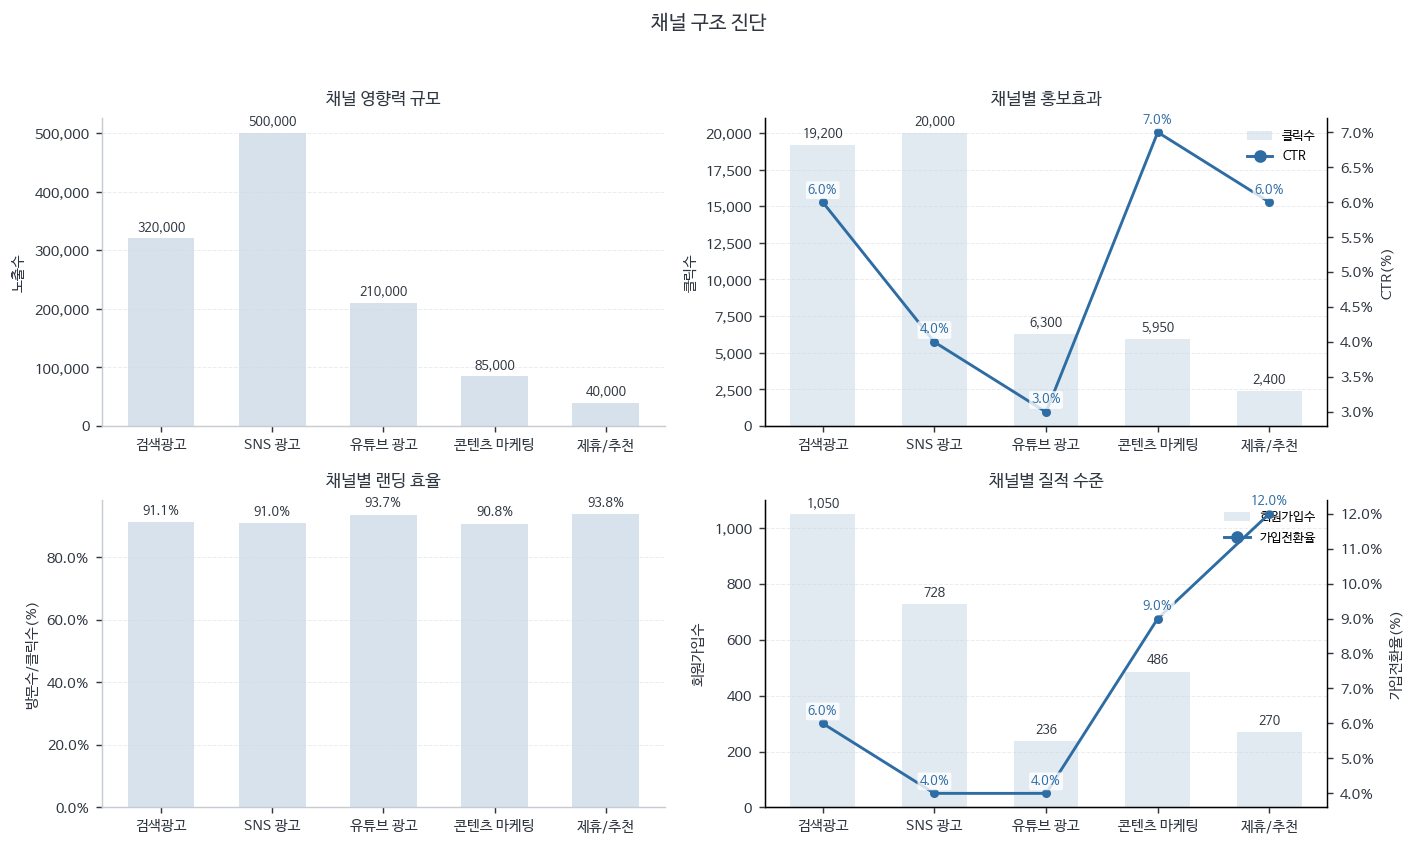

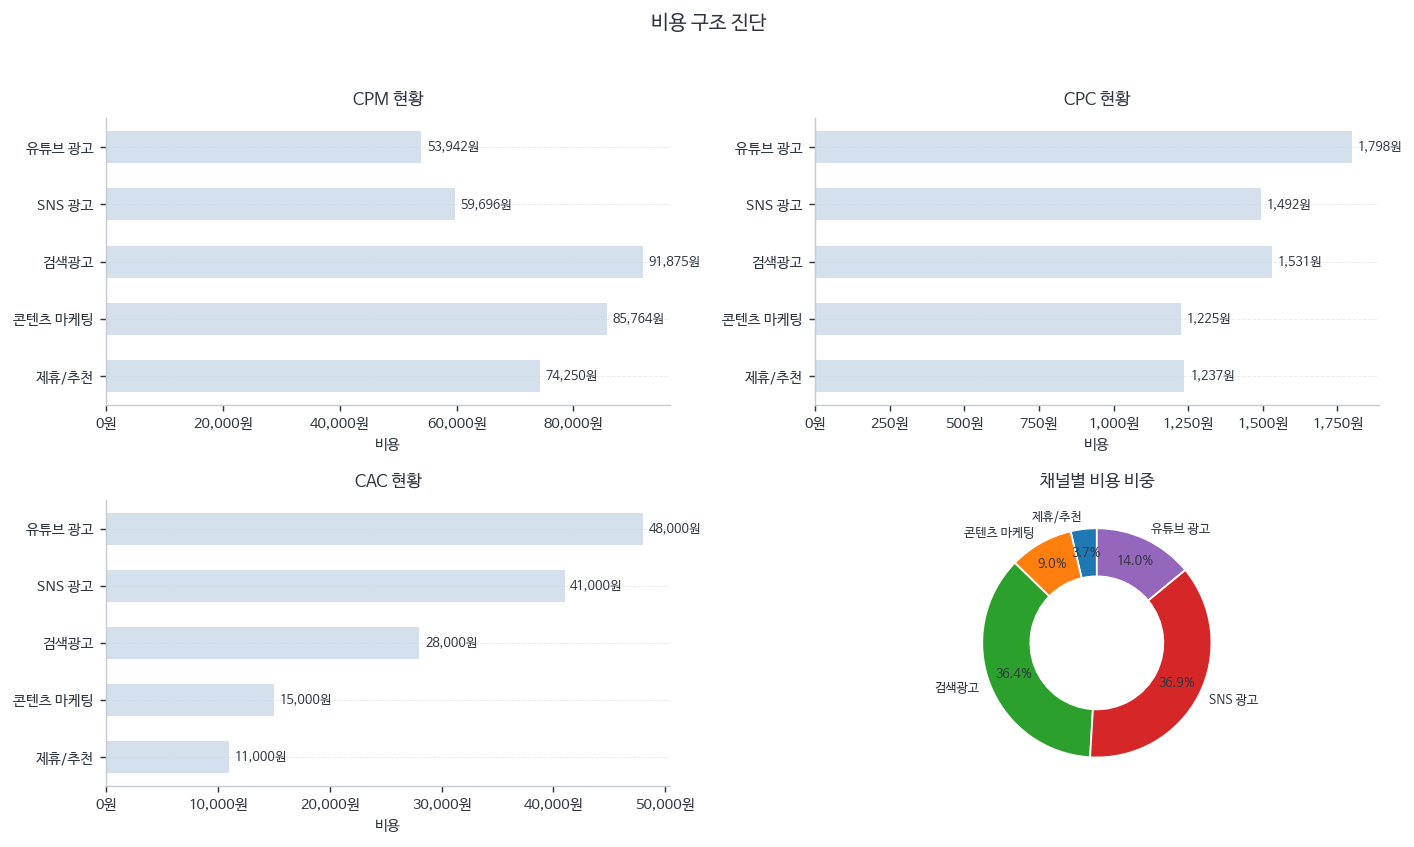

In [6]:
report = build_channel_report(channel_rows)
print(report["전체요약표"])
print(report["비용순위표"])
print(report["초과비용표"])
print(report["운영효율표"])

report["시각자료"]["채널구조진단"].show()
report["시각자료"]["비용구조진단"].show()
report['초과비용표']
report['운영효율표']
report['비용순위표']
report['운영효율표']
report['비용순위표']

,단계,유입수,이탈수,이탈률,평균대비차이(%p),이상구간여부
0,랜딩 진입,49250,9850.0,NaN,NaN,
1,소개 섹션,39400,17730.0,0.200,-27.85,
2,가격 섹션,21670,11820.0,0.450,-2.85,
3,회원가입 클릭,9850,7080.0,0.545,6.65,
4,회원가입 완료,2770,0.0,0.719,24.05,주의


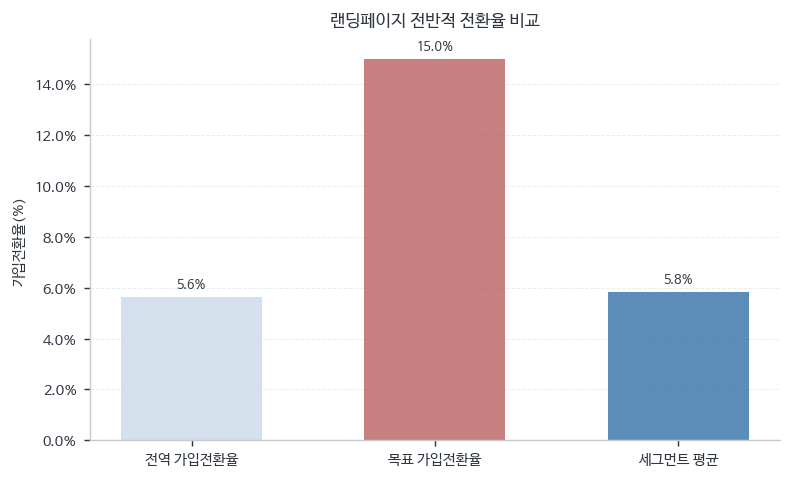

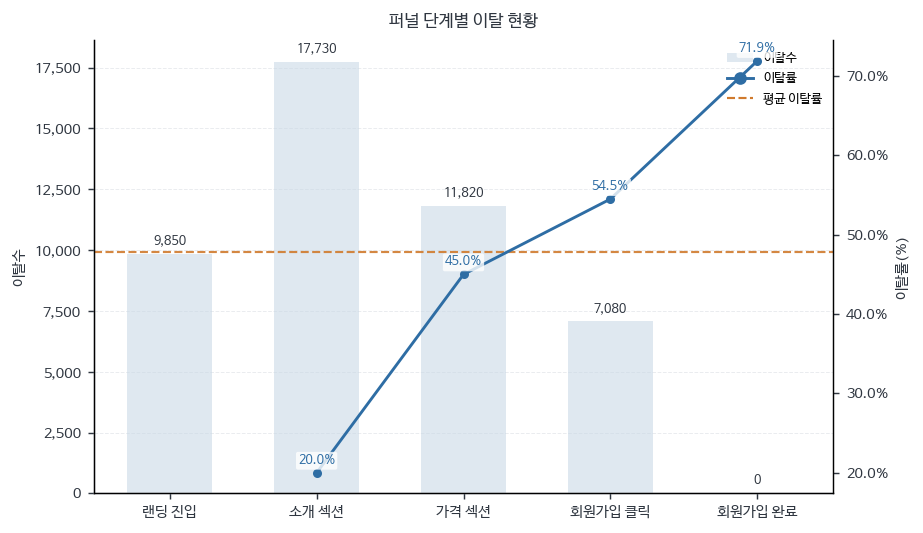

In [7]:
landing_report = build_landing_report(
    funnel_rows=funnel_rows,
    total_visit_counts=49250,
    total_sign_counts=2770,
    target_sign_rate=0.15,
    segment_rows=segment_rows
)

landing_report["전환율비교표"]
landing_report["퍼널단계요약표"]

,세그먼트,유입비중,전환율,추정유입수,추정전환수,전환비중,유입-전환 갭(%p),유입×전환 인덱스,진단
0,학생,0.18,0.032,8865,284,0.092238,-14.8,0.00576,우선순위 낮음
1,직장인,0.37,0.078,18222,1421,0.461513,-29.2,0.02886,핵심 타깃
2,프리랜서,0.24,0.069,11820,816,0.265021,-17.1,0.01656,잠재력 높은 타깃
3,팀/조직,0.21,0.054,10342,558,0.181228,-15.6,0.01134,우선순위 낮음


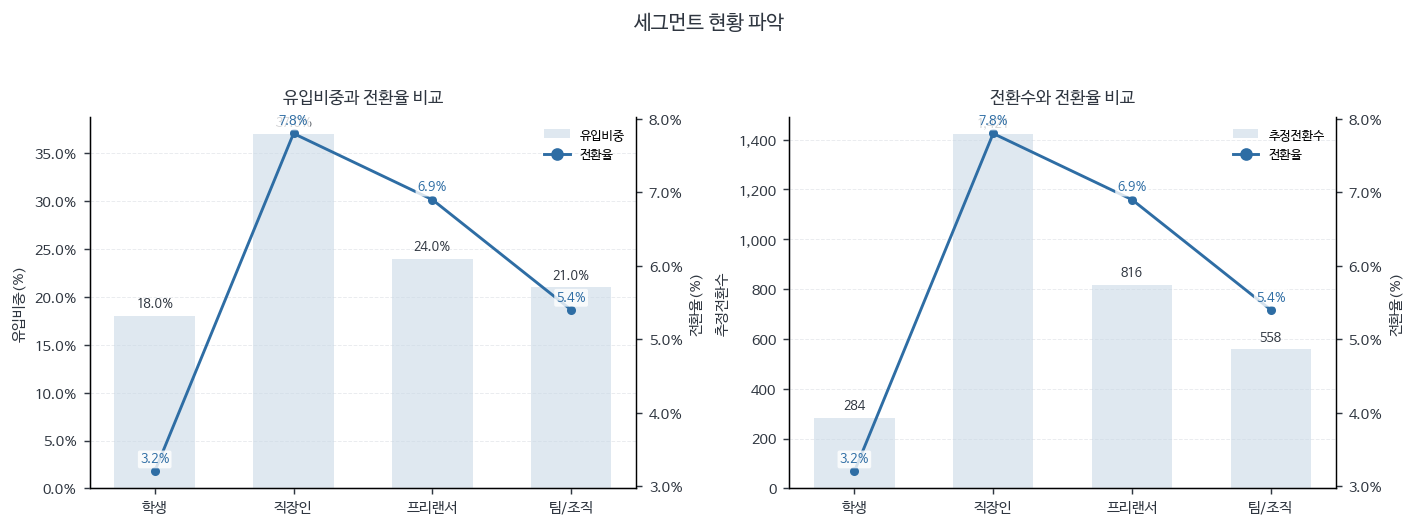

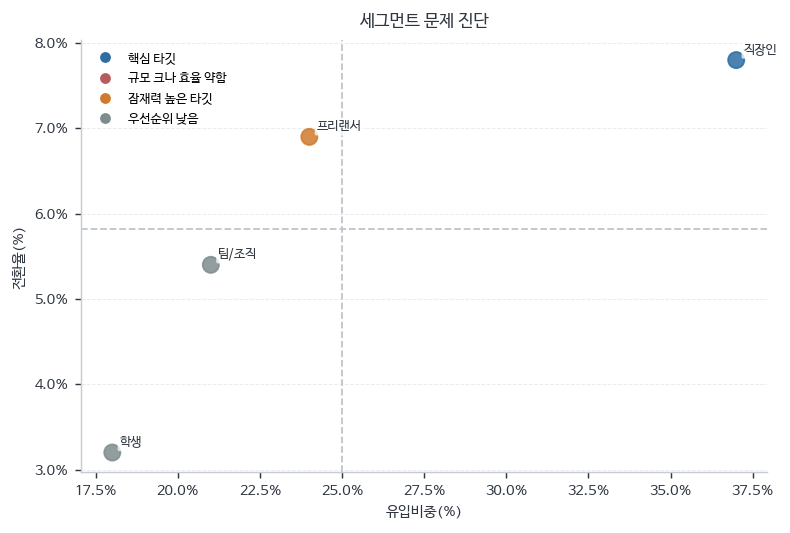

In [8]:
segment_report = build_segment_report(
    segment_rows=segment_rows,
    total_visit_counts=49250
)

segment_report["전체요약표"]
segment_report["인덱스순위표"]

# segment_report["시각자료"]["세그먼트현황"].show()
# segment_report["시각자료"]["세그먼트문제진단"].show()
segment_report["전체요약표"]